In [90]:
import seaborn as sn 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import plotly.express as px 
import plotly.graph_objects as go 
import warnings
warnings.filterwarnings('ignore')

In [91]:
df = pd.read_csv('f1_strategy_dataset_v4.csv')
df

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101366,ZHO,52,HARD,3,29.0,12,103.373,United States Grand Prix,2022,26.850,-90.264,0,0,0.722222,0.852941,2.0
101367,ZHO,53,HARD,3,30.0,13,105.200,United States Grand Prix,2022,27.061,-88.437,0,0,0.736111,0.882353,1.0
101368,ZHO,54,HARD,3,31.0,13,104.102,United States Grand Prix,2022,27.149,-89.535,0,0,0.750000,0.911765,0.0
101369,ZHO,55,HARD,3,32.0,14,103.812,United States Grand Prix,2022,4.428,-89.825,0,0,0.763889,0.941176,-1.0


In [92]:
df.shape

(101371, 16)

In [93]:
df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [95]:
df.isnull().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [96]:
df.columns

Index(['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'Race', 'Year', 'LapTime_Delta',
       'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress',
       'Normalized_TyreLife', 'Position_Change'],
      dtype='object')

<Axes: xlabel='TyreLife', ylabel='LapTime (s)'>

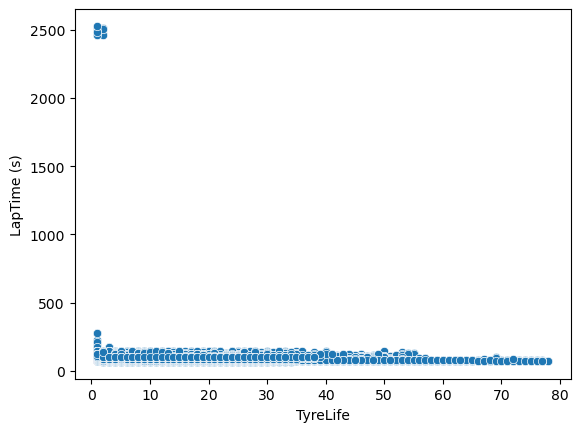

In [97]:
sn.scatterplot(x = 'TyreLife' , y = 'LapTime (s)' , data = df)

In [98]:
# filling the compound 

df['Compound'] = df['Compound'].fillna(df['Compound'].mode()[0])
print(df['Compound'].isnull().sum())

0


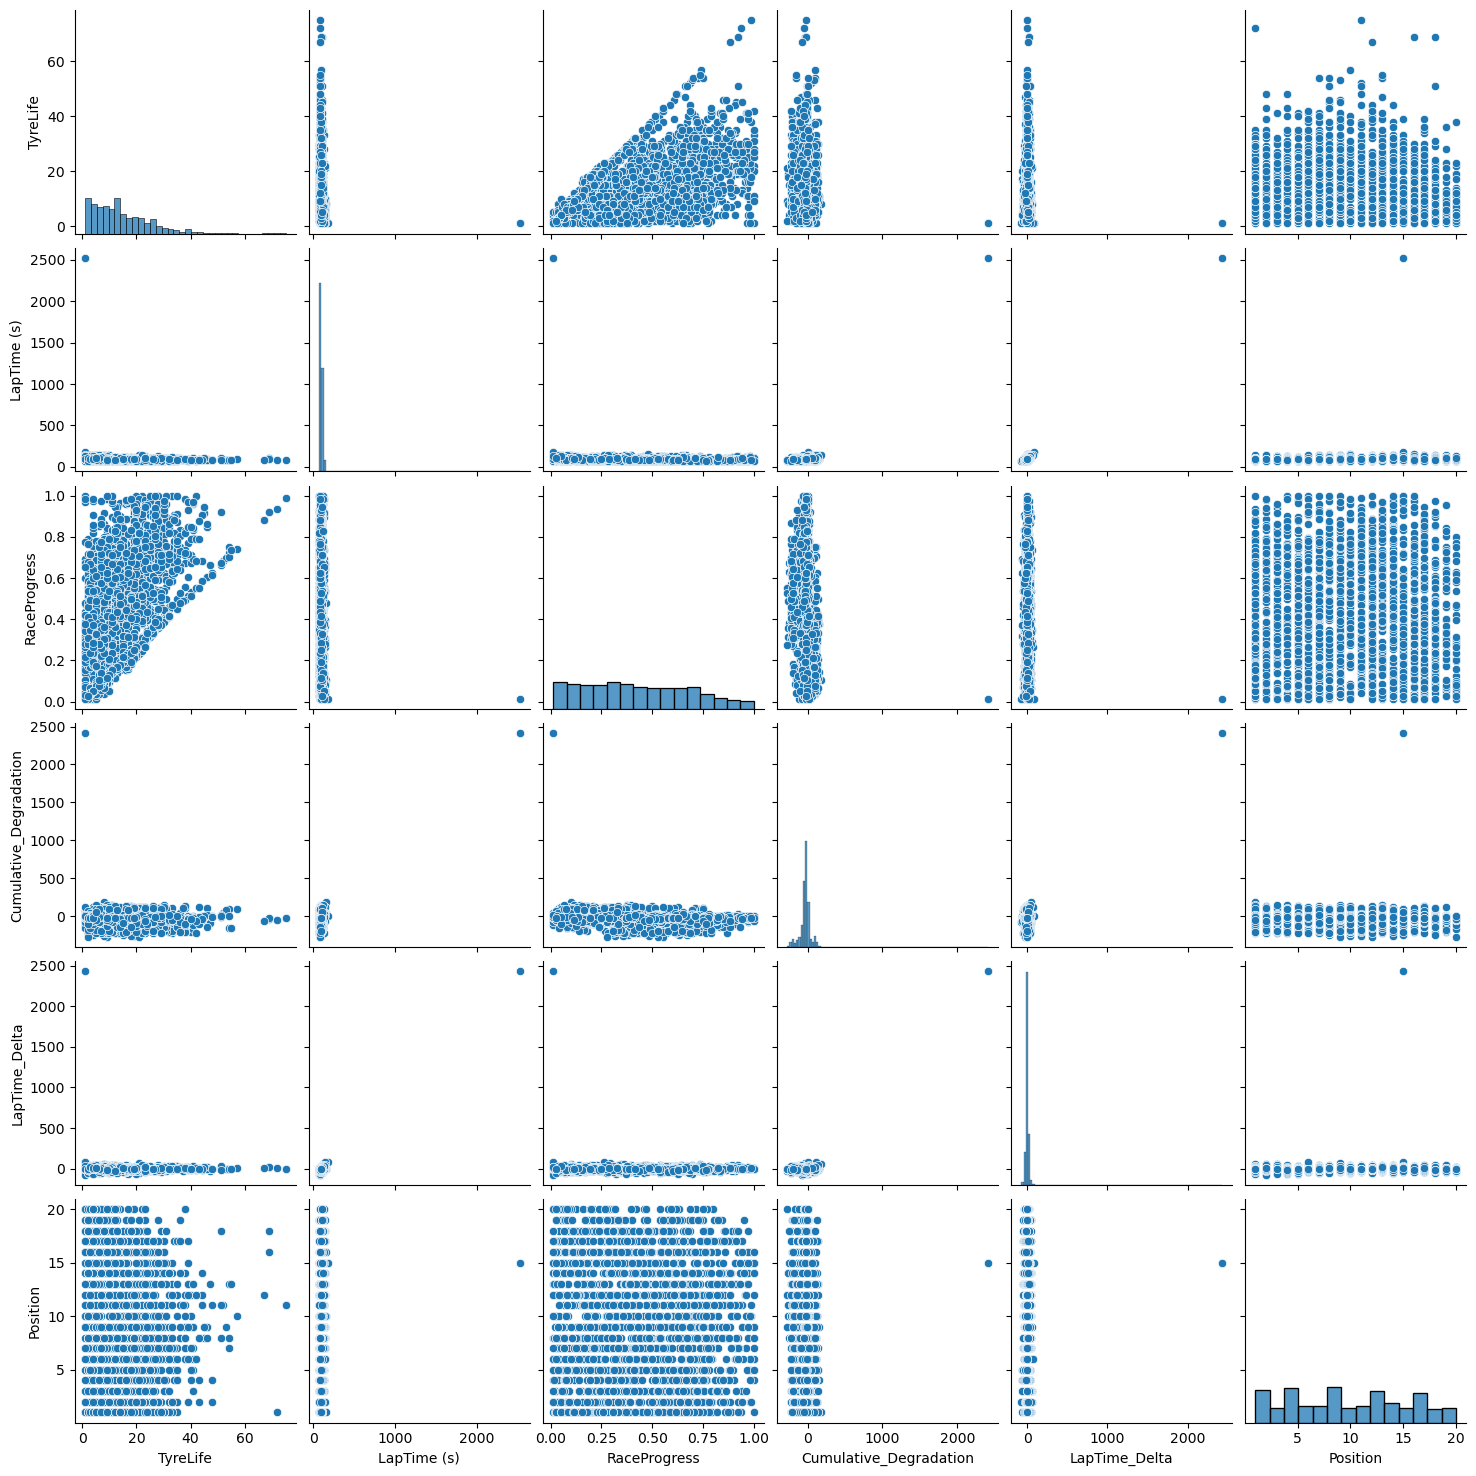

In [99]:
cols = [
    'TyreLife',
    'LapTime (s)',
    'RaceProgress',
    'Cumulative_Degradation',
    'LapTime_Delta',
    'Position'
]

sample_df = df[cols].sample(2000 , random_state=42)
sn.pairplot(sample_df) 

<Axes: >

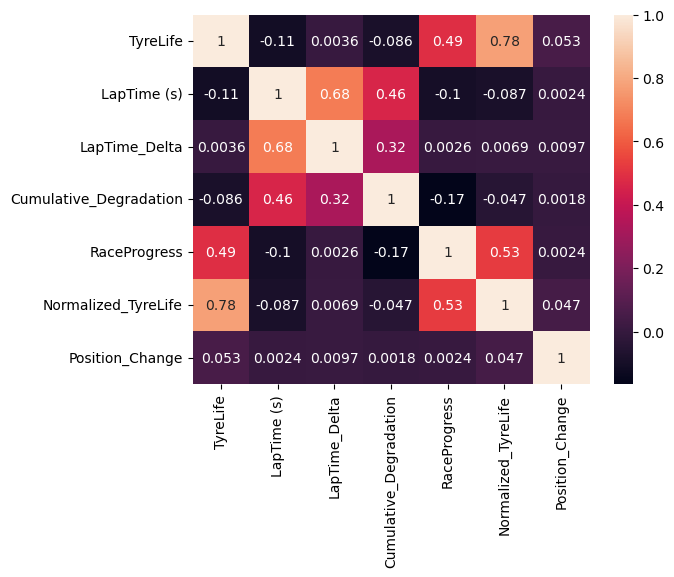

In [100]:
# checking Corr 
float_cols = df.select_dtypes(include='float').corr()
sn.heatmap(float_cols, annot=True )

In [101]:
# filling compound with mean 

print(df['Compound'].unique())
df['Compound'] = df.groupby(['Driver','Stint'])['Compound'].transform(lambda x: x.fillna(x.mode()[0] if x.mode().empty else np.nan))

df['Compound'] = df.groupby('Driver')['Compound'].ffill().bfill()

['MEDIUM' 'HARD' 'SOFT' 'INTERMEDIATE' 'WET']


In [102]:
print(df[df.duplicated(keep=False)])

Empty DataFrame
Columns: [Driver, LapNumber, Compound, Stint, TyreLife, Position, LapTime (s), Race, Year, LapTime_Delta, Cumulative_Degradation, PitStop, PitNextLap, RaceProgress, Normalized_TyreLife, Position_Change]
Index: []


In [103]:
df.dtypes

Driver                     object
LapNumber                   int64
Compound                   object
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
Race                       object
Year                        int64
LapTime_Delta             float64
Cumulative_Degradation    float64
PitStop                     int64
PitNextLap                  int64
RaceProgress              float64
Normalized_TyreLife       float64
Position_Change           float64
dtype: object

### For XGBoost

> Encode categorical columns first.

* Label Encoding

In [104]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Driver' , 'Compound' , 'Race']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

### For LightGBM (Recommended)

> LightGBM can handle categorical features directly.

In [105]:
cat_colss =  ['Driver', 'Compound', 'Race']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [106]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,0,1,2,1,2.0,17,100.625,0,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,0,2,2,1,3.0,18,93.560,0,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,0,3,2,1,4.0,18,91.768,0,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,0,4,2,1,5.0,18,91.591,0,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,0,5,2,1,6.0,18,91.422,0,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [107]:
# Outliers Detection 

num_cols = [
    'LapNumber',
    'Stint',
    'TyreLife',
    'Position',
    'LapTime (s)',
    'Year',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'PitStop',
    'PitNextLap',
    'RaceProgress',
    'Normalized_TyreLife',
    'Position_Change'
]

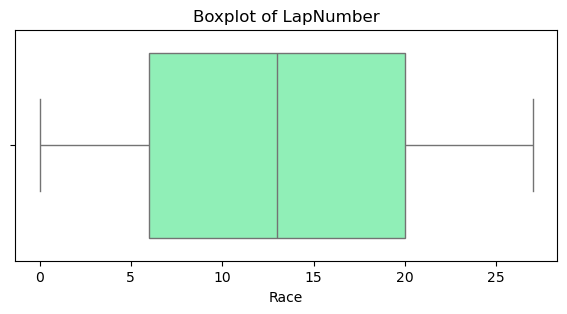

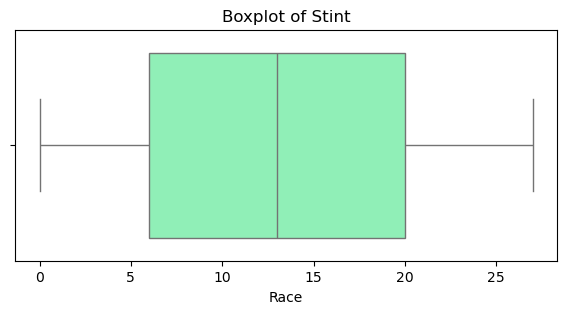

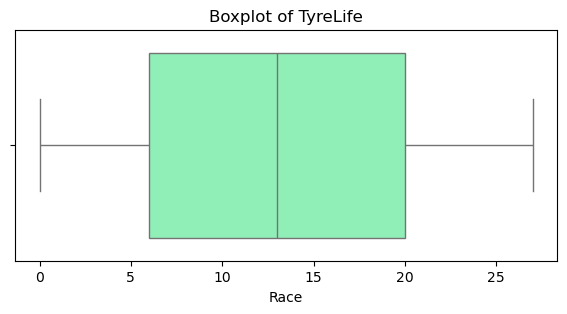

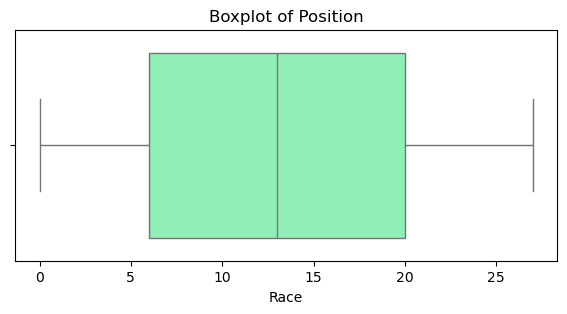

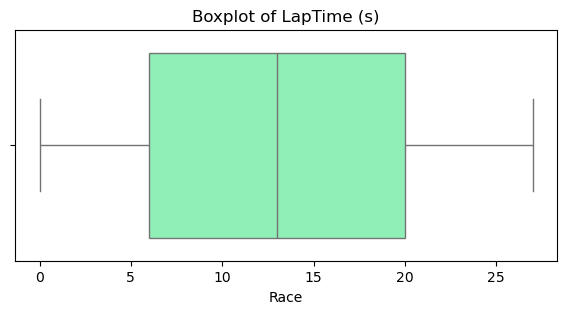

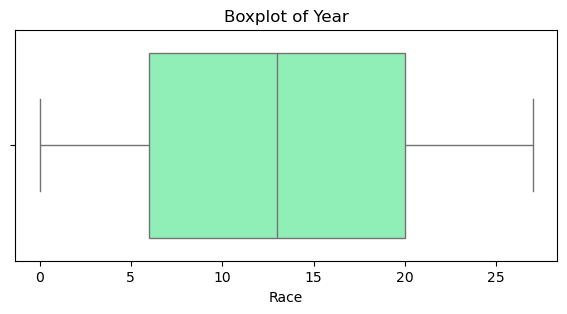

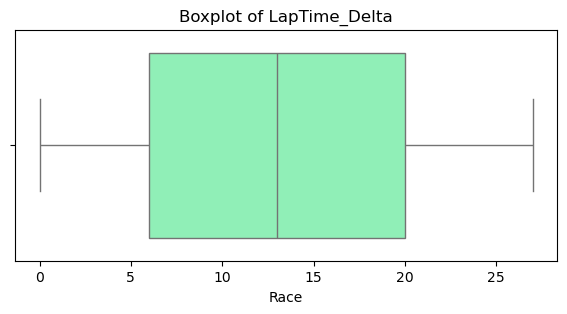

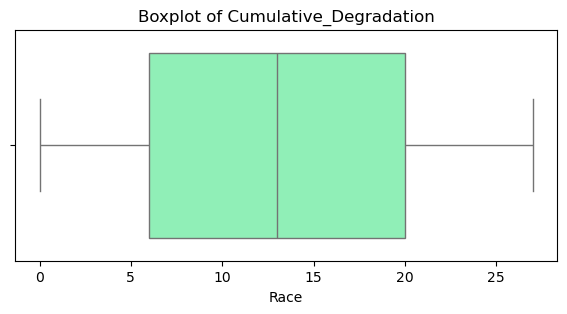

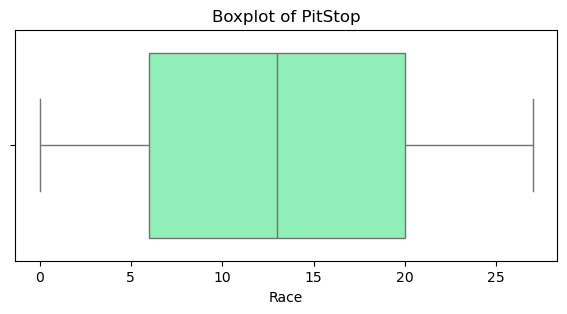

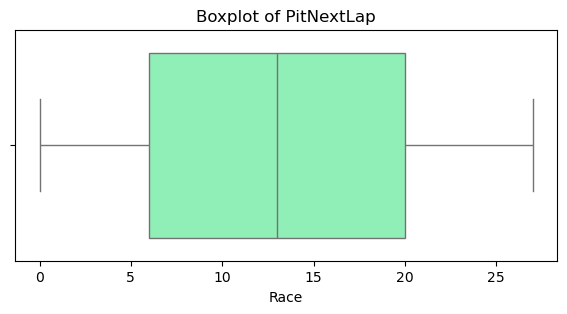

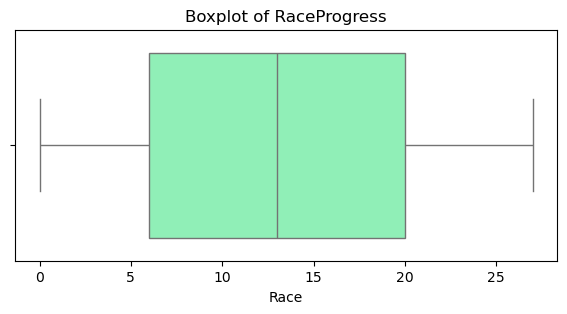

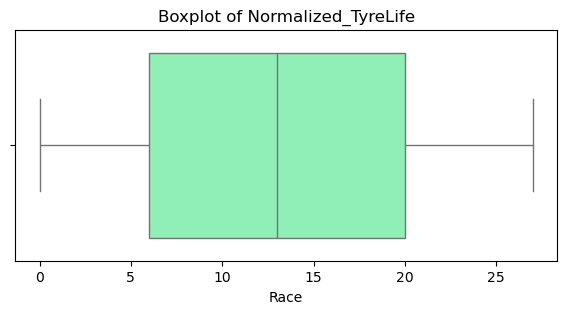

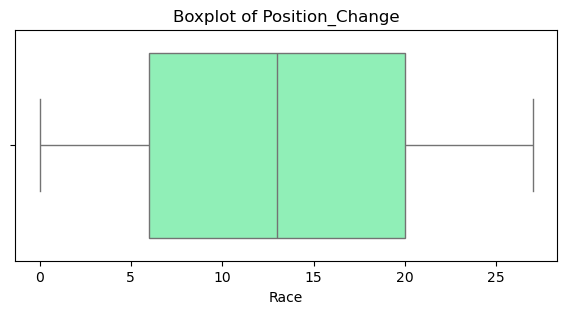

In [108]:
for num in num_cols:
    plt.figure(figsize=(7, 3))
    sn.boxplot(x=df[col], palette='rainbow')
    plt.title(f"Boxplot of {num}")
    plt.show()

## Here's a single combined EDA block for your F1 pit-stop project that:

* Fixes LapTime_Delta
* Fixes Position_Change
* Removes extreme bad rows
* Shows target imbalance
* Shows TyreLife statistics
* Creates TyreLife plots
* Creates LapTime_Delta plots
* Runs Mann-Whitney tests
* Runs Chi-Square test for Compound

In [109]:
print(df['PitNextLap'].value_counts(normalize=True) * 100)

PitNextLap
0    74.520326
1    25.479674
Name: proportion, dtype: float64


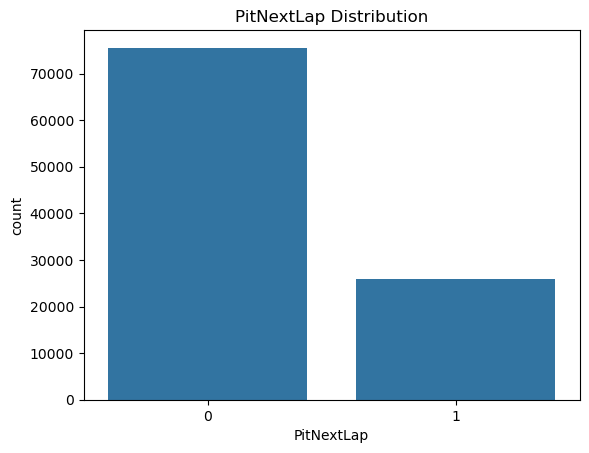

In [110]:
sn.countplot(x='PitNextLap', data=df)
plt.title('PitNextLap Distribution')
plt.show()

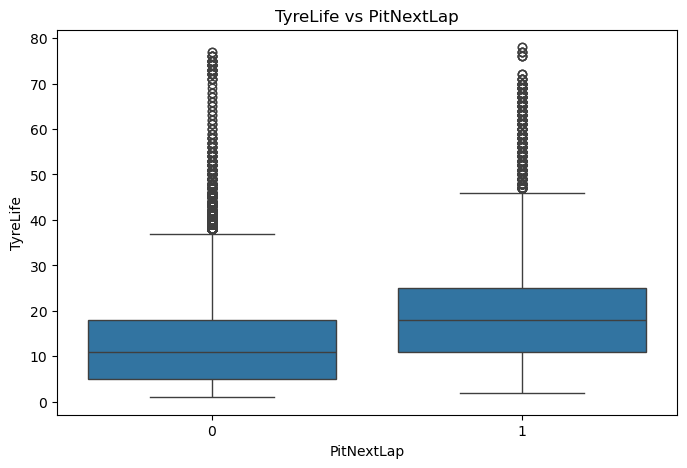

In [111]:
# TyreLife vs PitNextLap

plt.figure(figsize=(8,5))
sn.boxplot(x='PitNextLap', y='TyreLife', data=df)
plt.title('TyreLife vs PitNextLap')
plt.show()

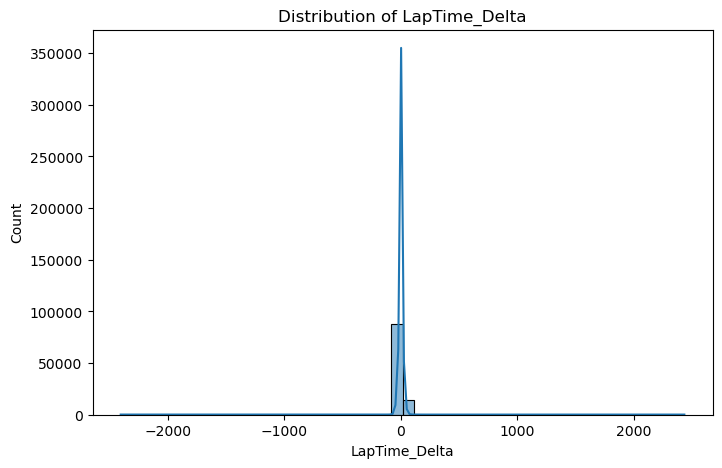

In [112]:
# LapTime_Delta Distribution 

plt.figure(figsize=(8,5))
sn.histplot(df['LapTime_Delta'], bins=50, kde=True)
plt.title('Distribution of LapTime_Delta')
plt.show()

In [113]:
df.groupby('PitNextLap')['TyreLife'].mean()

PitNextLap
0    12.944005
1    19.244454
Name: TyreLife, dtype: float64

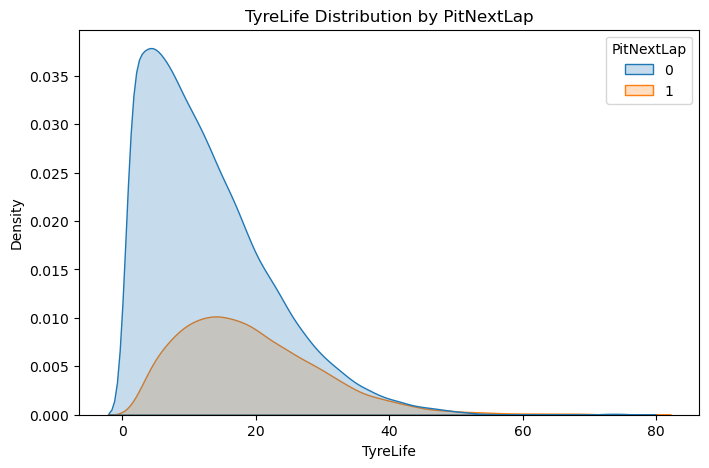

In [114]:

plt.figure(figsize=(8,5))
sn.kdeplot(data=df, x='TyreLife', hue='PitNextLap', fill=True)
plt.title('TyreLife Distribution by PitNextLap')
plt.show()

In [115]:
# Statistical significance \

from scipy.stats import mannwhitneyu

group0 = df[df['PitNextLap']==0]['TyreLife']
group1 = df[df['PitNextLap']==1]['TyreLife']

stat, p = mannwhitneyu(group0, group1)

print("p-value:", p)

p-value: 0.0


In [116]:
df['LapTime_Delta'].describe()

count    101371.000000
mean         -0.203891
std          45.344910
min       -2403.895000
25%          -7.253000
50%          -0.027000
75%           5.705000
max        2433.472000
Name: LapTime_Delta, dtype: float64

In [117]:
# For Largest +ve value

df.nlargest(10, 'LapTime_Delta')[
    ['Driver','Race','LapNumber','LapTime_Delta','PitNextLap']
]

,Driver,Race,LapNumber,LapTime_Delta,PitNextLap
44809,30,18,1,2433.472,0
43812,5,18,1,2429.475,0
44503,25,18,1,2423.782,0
43736,1,18,1,2419.536,1
44273,22,18,1,2418.256,0
44579,26,18,1,2412.173,1
43888,9,18,1,2406.326,0
43659,0,18,1,2403.805,0
44655,27,18,1,2400.353,0
43965,11,18,1,2396.693,0


In [118]:
# For Largest -ve value 
df.nsmallest(10, 'LapTime_Delta')[
    ['Driver','Race','LapNumber','LapTime_Delta','PitNextLap']
]

,Driver,Race,LapNumber,LapTime_Delta,PitNextLap
32278,1,7,1,-2403.895,0
33424,30,7,1,-2402.690,0
32348,5,7,1,-2399.941,0
33191,25,7,1,-2399.173,0
32999,22,7,1,-2396.302,0
33214,26,7,1,-2389.566,0
32226,0,7,1,-2379.030,0
32418,9,7,1,-2377.034,0
33354,28,7,1,-2373.951,0
33284,27,7,1,-2373.904,0


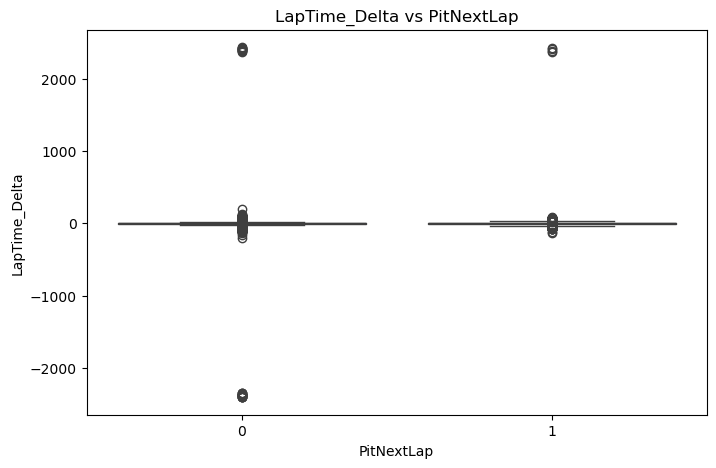

In [119]:
plt.figure(figsize=(8,5))
sn.boxplot(
    x='PitNextLap',
    y='LapTime_Delta',
    data=df
)
plt.title('LapTime_Delta vs PitNextLap')
plt.show()

In [120]:
df['LapTime_Delta'] = df['LapTime (s)'].diff()

In [121]:
df[df['LapNumber'] == 1][
    ['Race','Driver','LapNumber','LapTime (s)','LapTime_Delta']
].head(20)

,Race,Driver,LapNumber,LapTime (s),LapTime_Delta
0,0,0,1,100.625,NaN
58,0,1,1,96.044,7.374
116,0,5,1,100.300,11.594
173,0,9,1,96.636,6.086
231,0,11,1,97.227,7.680
289,0,12,1,99.291,8.397
347,0,15,1,93.119,3.902
405,0,16,1,101.597,10.313
462,0,18,1,94.309,3.053
520,0,19,1,98.197,9.609


In [122]:
df = df.sort_values(['Race', 'Driver', 'LapNumber'])

df['LapTime_Delta'] = (
    df.groupby(['Race', 'Driver'])['LapTime (s)']
      .diff()
)

In [123]:
df['LapTime_Delta'] = df['LapTime_Delta'].fillna(0)

In [124]:
# Verify after recalculation 
df[df['LapNumber'] == 1][
    ['Race','Driver','LapNumber','LapTime_Delta']
].head(20)

,Race,Driver,LapNumber,LapTime_Delta
0,0,0,1,0.000
24914,0,0,1,0.565
52471,0,0,1,-1.433
58,0,1,1,0.000
24971,0,1,1,0.122
52529,0,1,1,-1.186
52587,0,2,1,0.000
52645,0,3,1,0.000
52703,0,4,1,0.000
116,0,5,1,0.000


In [125]:
# Check  other engineered features too

# Cumulative_Degradation
# Position_Change
# Normalized_TyreLife
# RaceProgress
df.groupby(['Race','Driver'])['Position'].diff()

0         NaN
24914    -2.0
52471     0.0
1         3.0
24915    -3.0
         ... 
101368   -6.0
24913     2.0
52470     4.0
101369   -5.0
101370    0.0
Name: Position, Length: 101371, dtype: float64

In [126]:
df['Position'].diff()

0         NaN
24914    -2.0
52471     0.0
1         3.0
24915    -3.0
         ... 
101368   -6.0
24913     2.0
52470     4.0
101369   -5.0
101370    0.0
Name: Position, Length: 101371, dtype: float64

In [127]:
df[['Race','Driver','LapNumber']].duplicated().sum()

np.int64(57603)

In [128]:
df = df.sort_values(
    ['Year','Race','Driver','LapNumber']
)

df['LapTime_Delta'] = (
    df.groupby(['Year','Race','Driver'])['LapTime (s)']
      .diff()
      .fillna(0)
)

df['Position_Change'] = (
    df.groupby(['Year','Race','Driver'])['Position']
      .diff()
      .fillna(0)
)

In [129]:
df[['Year','Race','Driver','LapNumber']].duplicated().sum()

np.int64(0)

In [130]:
group_cols = ['Year', 'Race', 'Driver']
df = df.sort_values(['Year', 'Race', 'Driver', 'LapNumber'])
df['LapTime_Delta'] = (
    df.groupby(group_cols)['LapTime (s)']
      .diff()
      .fillna(0)
)

In [131]:
df['Position_Change'] = (
    df.groupby(group_cols)['Position']
      .diff()
      .fillna(0)
)

In [132]:
# Checking 1st Lap

df[df['LapNumber'] == 1][
    ['Year','Race','Driver','LapTime_Delta','Position_Change']
].head(20)

,Year,Race,Driver,LapTime_Delta,Position_Change
79511,2022,1,0,0.0,0.0
79569,2022,1,1,0.0,0.0
79625,2022,1,5,0.0,0.0
79682,2022,1,9,0.0,0.0
79739,2022,1,11,0.0,0.0
79796,2022,1,13,0.0,0.0
79853,2022,1,15,0.0,0.0
79909,2022,1,16,0.0,0.0
79965,2022,1,17,0.0,0.0
80021,2022,1,18,0.0,0.0


In [133]:
df['LapTime_Delta'].describe()

count    101371.000000
mean         -0.649942
std          30.880050
min       -2414.122000
25%          -0.324000
50%          -0.004000
75%           0.285000
max          61.267000
Name: LapTime_Delta, dtype: float64

In [134]:
df['Cumulative_Degradation'] = (
    df.groupby(group_cols)['LapTime_Delta']
      .cumsum()
)

In [135]:
# Find the bad rows
df.nsmallest(
    20,
    'LapTime_Delta'
)[
    ['Year','Race','Driver','LapNumber','LapTime (s)','LapTime_Delta']
]


,Year,Race,Driver,LapNumber,LapTime (s),LapTime_Delta
44810,2024,18,30,2,112.131,-2414.122
43813,2024,18,5,2,116.358,-2405.390
43966,2024,18,11,3,87.058,-2396.746
44504,2024,18,25,2,121.235,-2395.623
44733,2024,18,28,3,85.744,-2393.200
43737,2024,18,1,2,124.571,-2388.613
44350,2024,18,23,3,85.319,-2388.565
44120,2024,18,18,3,85.283,-2382.759
44427,2024,18,24,3,85.012,-2377.709
44274,2024,18,22,2,130.108,-2377.499


In [136]:
df[df['LapTime_Delta'] < -100][
    ['Year','Race','Driver','LapNumber','LapTime (s)','LapTime_Delta']
].sort_values('LapTime_Delta')

,Year,Race,Driver,LapNumber,LapTime (s),LapTime_Delta
44810,2024,18,30,2,112.131,-2414.122
43813,2024,18,5,2,116.358,-2405.390
43966,2024,18,11,3,87.058,-2396.746
44504,2024,18,25,2,121.235,-2395.623
44733,2024,18,28,3,85.744,-2393.200
43737,2024,18,1,2,124.571,-2388.613
44350,2024,18,23,3,85.319,-2388.565
44120,2024,18,18,3,85.283,-2382.759
44427,2024,18,24,3,85.012,-2377.709
44274,2024,18,22,2,130.108,-2377.499


In [137]:
# If it's only a few rows
(df['LapTime_Delta'] < -100).sum()

np.int64(18)

In [138]:
# Sort data properly
df = df.sort_values(
    ['Year', 'Race', 'Driver', 'LapNumber']
)

group_cols = ['Year', 'Race', 'Driver']

# Recalculate LapTime_Delta
df['LapTime_Delta'] = (
    df.groupby(group_cols)['LapTime (s)']
      .diff()
      .fillna(0)
)

# Recalculate Position_Change
df['Position_Change'] = (
    df.groupby(group_cols)['Position']
      .diff()
      .fillna(0)
)

# Find suspicious rows
bad_rows = df[df['LapTime_Delta'] < -100]

print("Number of suspicious rows:", len(bad_rows))

print("Most extreme rows:")
print(
    bad_rows[
        ['Year', 'Race', 'Driver',
         'LapNumber', 'LapTime (s)',
         'LapTime_Delta']
    ].sort_values('LapTime_Delta')
)

# Remove suspicious rows
df = df[df['LapTime_Delta'] >= -100]

# Reset index
df = df.reset_index(drop=True)

# Check final statistics
print("\nLapTime_Delta Summary:")
print(df['LapTime_Delta'].describe())

# Verify first laps
print("\nFirst Lap Validation:")
print(
    df[df['LapNumber'] == 1][
        ['Year', 'Race', 'Driver',
         'LapTime_Delta', 'Position_Change']
    ].head(20)
)

Number of suspicious rows: 18
Most extreme rows:
       Year Race Driver  LapNumber  LapTime (s)  LapTime_Delta
44810  2024   18     30          2      112.131      -2414.122
43813  2024   18      5          2      116.358      -2405.390
43966  2024   18     11          3       87.058      -2396.746
44504  2024   18     25          2      121.235      -2395.623
44733  2024   18     28          3       85.744      -2393.200
43737  2024   18      1          2      124.571      -2388.613
44350  2024   18     23          3       85.319      -2388.565
44120  2024   18     18          3       85.283      -2382.759
44427  2024   18     24          3       85.012      -2377.709
44274  2024   18     22          2      130.108      -2377.499
44197  2024   18     21          3       84.953      -2373.791
44043  2024   18     15          3       84.624      -2371.706
44580  2024   18     26          2      134.844      -2367.804
43889  2024   18      9          2      139.618      -2358.077
43660 

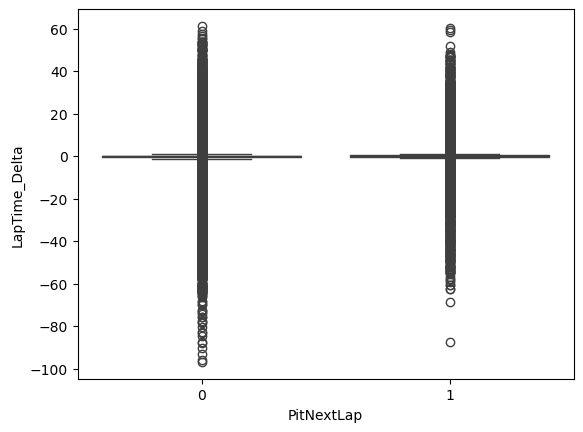

In [139]:
sn.boxplot(x='PitNextLap', y='LapTime_Delta', data=df)
plt.show()

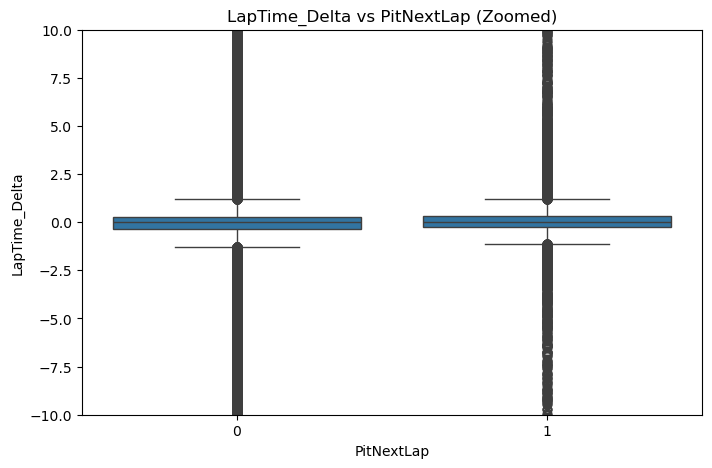

In [140]:
plt.figure(figsize=(8,5))
sn.boxplot(
    x='PitNextLap',
    y='LapTime_Delta',
    data=df
)
plt.ylim(-10, 10)
plt.title('LapTime_Delta vs PitNextLap (Zoomed)')
plt.show()

PitNextLap Distribution
PitNextLap
0    75508
1    25827
Name: count, dtype: int64

Percentage Distribution:
PitNextLap
0    74.51
1    25.49
Name: proportion, dtype: float64


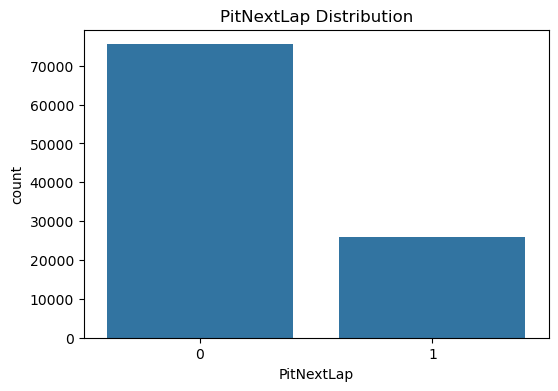



TyreLife Statistics
                 mean  median        std
PitNextLap                              
0           12.948760    11.0   9.624395
1           19.245751    18.0  10.813255


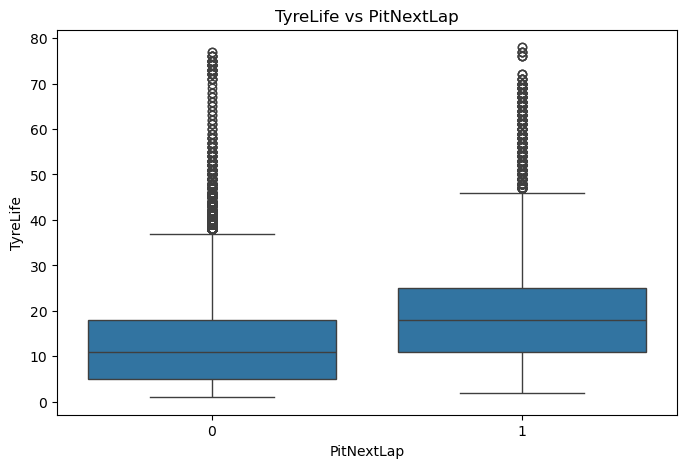

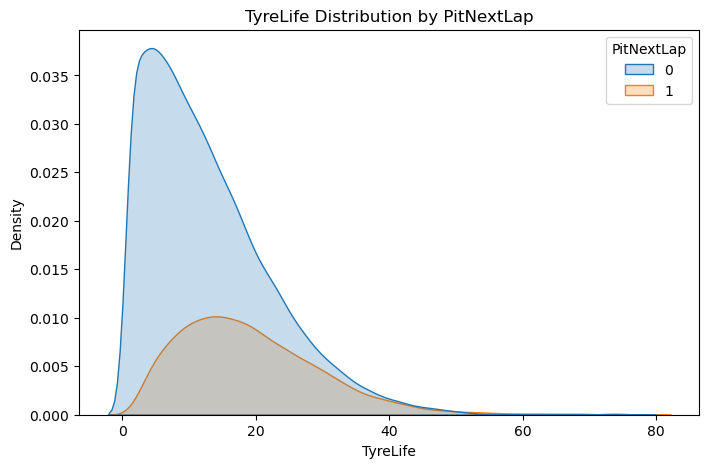


TyreLife Mann-Whitney p-value: 0.0


LapTime_Delta Summary
count    101335.000000
mean         -0.266866
std           7.678695
min         -96.859000
25%          -0.323000
50%          -0.004000
75%           0.285000
max          61.267000
Name: LapTime_Delta, dtype: float64


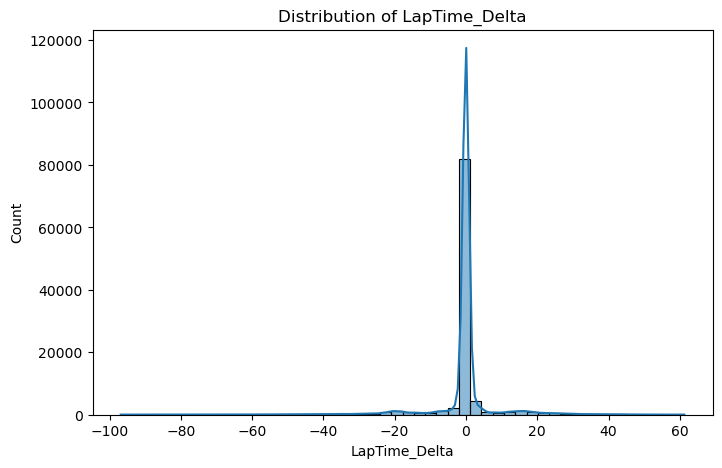

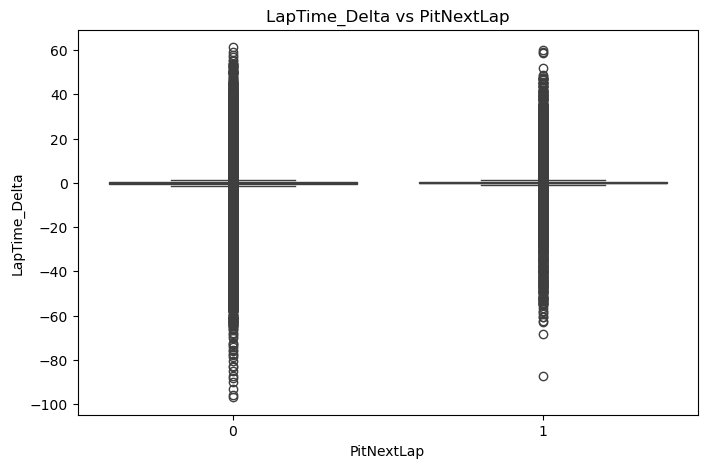

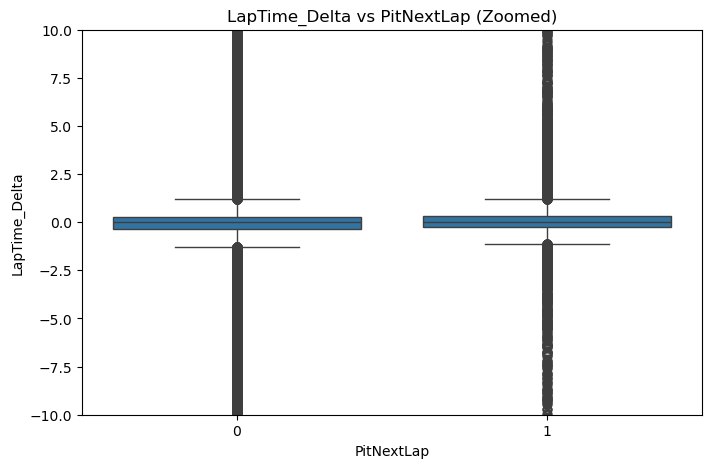


LapTime_Delta by Target
                mean  median       std
PitNextLap                            
0          -0.447857  -0.012  8.136893
1           0.262281   0.011  6.115708

LapTime_Delta Mann-Whitney p-value: 1.5903918468473798e-56


Compound vs PitNextLap
PitNextLap      0      1
Compound                
0           30502  14513
1            4474   1082
2           30445   7180
3            9695   3045
4             392      7

Chi-Square Statistic: 2134.530646916335
P-value: 0.0
Compound and PitNextLap are statistically related.


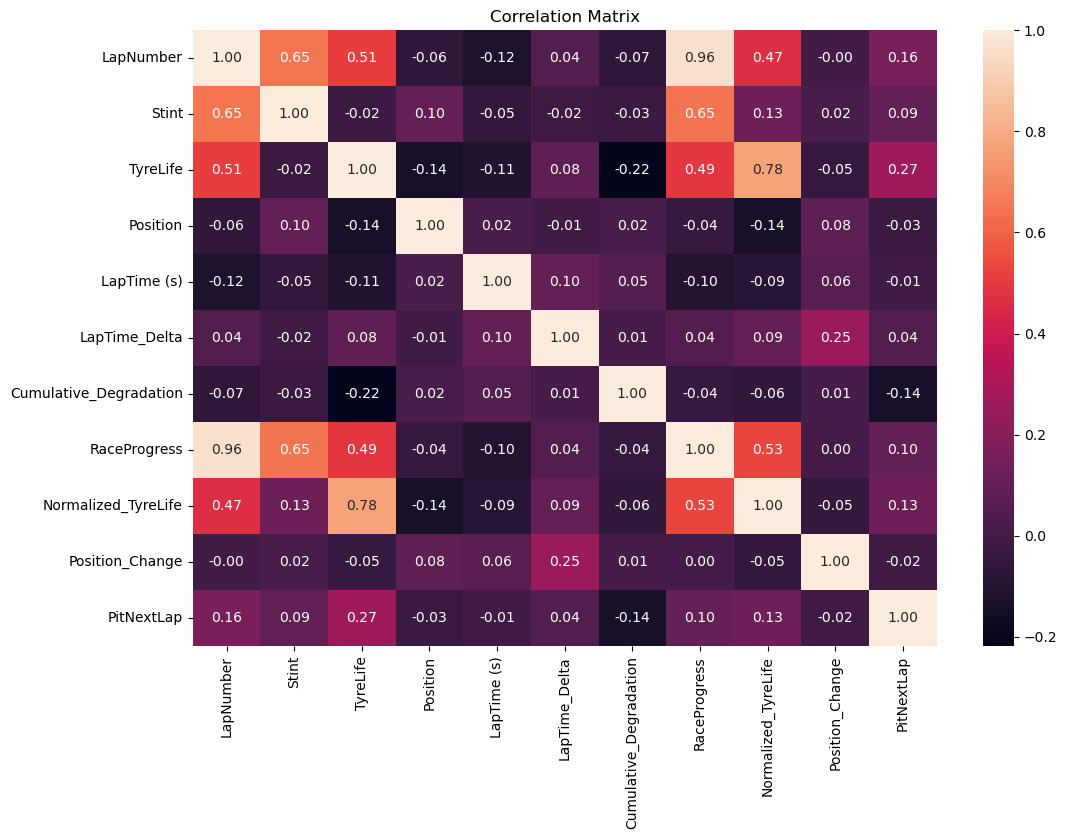

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency

# =====================================================
# 1. FIX FEATURE ENGINEERING
# =====================================================

group_cols = ['Year', 'Race', 'Driver']

df = df.sort_values(
    ['Year', 'Race', 'Driver', 'LapNumber']
)

# Lap Time Delta
df['LapTime_Delta'] = (
    df.groupby(group_cols)['LapTime (s)']
      .diff()
      .fillna(0)
)

# Position Change
df['Position_Change'] = (
    df.groupby(group_cols)['Position']
      .diff()
      .fillna(0)
)

# Remove suspicious rows
df = df[df['LapTime_Delta'] >= -100]

# =====================================================
# 2. TARGET IMBALANCE
# =====================================================

print("="*50)
print("PitNextLap Distribution")
print("="*50)

print(df['PitNextLap'].value_counts())

print("\nPercentage Distribution:")
print(
    round(
        df['PitNextLap'].value_counts(normalize=True)*100,
        2
    )
)

plt.figure(figsize=(6,4))
sns.countplot(x='PitNextLap', data=df)
plt.title('PitNextLap Distribution')
plt.show()

# =====================================================
# 3. TYRELIFE ANALYSIS
# =====================================================

print("\n")
print("="*50)
print("TyreLife Statistics")
print("="*50)

print(
    df.groupby('PitNextLap')['TyreLife']
      .agg(['mean','median','std'])
)

plt.figure(figsize=(8,5))
sns.boxplot(
    x='PitNextLap',
    y='TyreLife',
    data=df
)
plt.title('TyreLife vs PitNextLap')
plt.show()

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='TyreLife',
    hue='PitNextLap',
    fill=True
)
plt.title('TyreLife Distribution by PitNextLap')
plt.show()

# Mann Whitney Test
g0 = df[df['PitNextLap']==0]['TyreLife']
g1 = df[df['PitNextLap']==1]['TyreLife']

stat, p = mannwhitneyu(g0, g1)

print("\nTyreLife Mann-Whitney p-value:", p)

# =====================================================
# 4. LAPTIME DELTA ANALYSIS
# =====================================================

print("\n")
print("="*50)
print("LapTime_Delta Summary")
print("="*50)

print(df['LapTime_Delta'].describe())

plt.figure(figsize=(8,5))
sns.histplot(
    df['LapTime_Delta'],
    bins=50,
    kde=True
)
plt.title('Distribution of LapTime_Delta')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    x='PitNextLap',
    y='LapTime_Delta',
    data=df
)
plt.title('LapTime_Delta vs PitNextLap')
plt.show()

# Zoomed version
plt.figure(figsize=(8,5))
sns.boxplot(
    x='PitNextLap',
    y='LapTime_Delta',
    data=df
)
plt.ylim(-10,10)
plt.title('LapTime_Delta vs PitNextLap (Zoomed)')
plt.show()

print("\nLapTime_Delta by Target")

print(
    df.groupby('PitNextLap')['LapTime_Delta']
      .agg(['mean','median','std'])
)

g0 = df[df['PitNextLap']==0]['LapTime_Delta']
g1 = df[df['PitNextLap']==1]['LapTime_Delta']

stat, p = mannwhitneyu(g0, g1)

print("\nLapTime_Delta Mann-Whitney p-value:", p)

# =====================================================
# 5. COMPOUND vs PITNEXTLAP
# =====================================================

print("\n")
print("="*50)
print("Compound vs PitNextLap")
print("="*50)

compound_table = pd.crosstab(
    df['Compound'],
    df['PitNextLap']
)

print(compound_table)

chi2, p, dof, expected = chi2_contingency(compound_table)

print("\nChi-Square Statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Compound and PitNextLap are statistically related.")
else:
    print("No significant relationship found.")

# =====================================================
# 6. CORRELATION CHECK
# =====================================================

numeric_cols = [
    'LapNumber',
    'Stint',
    'TyreLife',
    'Position',
    'LapTime (s)',
    'LapTime_Delta',
    'Cumulative_Degradation',
    'RaceProgress',
    'Normalized_TyreLife',
    'Position_Change',
    'PitNextLap'
]

plt.figure(figsize=(12,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f'
    
)
plt.title('Correlation Matrix')
plt.show()

In [142]:
from scipy.stats import chi2_contingency

compound_table = pd.crosstab(
    df['Compound'],
    df['PitNextLap']
)

print(compound_table)

chi2, p, dof, expected = chi2_contingency(compound_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)

PitNextLap      0      1
Compound                
0           30502  14513
1            4474   1082
2           30445   7180
3            9695   3045
4             392      7
Chi-Square Statistic: 2134.530646916335
P-value: 0.0


In [143]:
if p < 0.05:
    print("Compound and PitNextLap are statistically related.")
else:
    print("No significant relationship found.")

Compound and PitNextLap are statistically related.


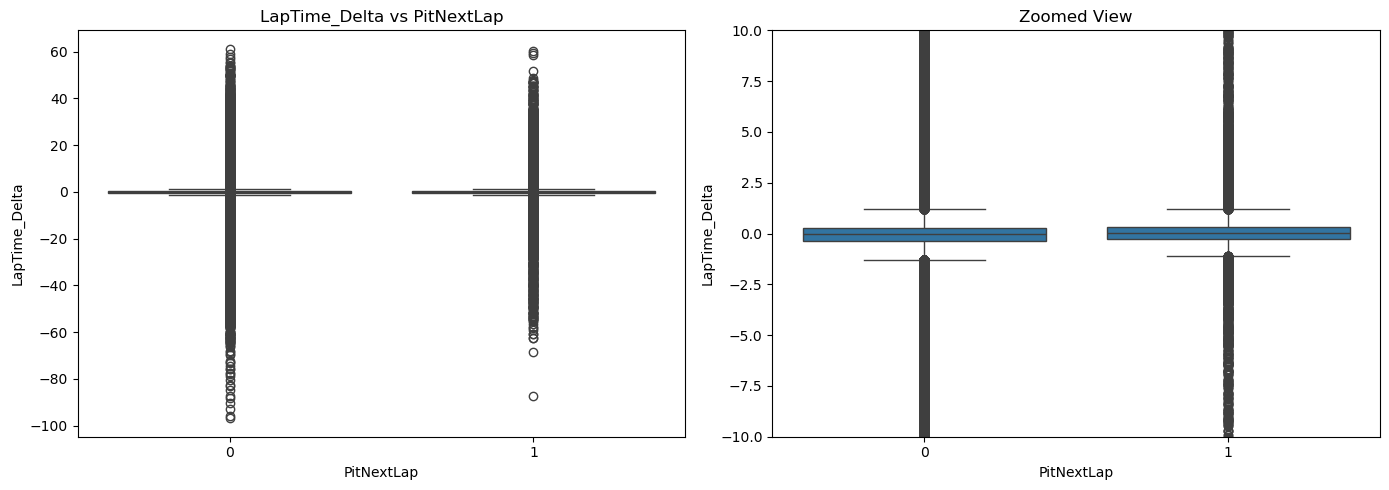

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sn.boxplot(x='PitNextLap', y='LapTime_Delta', data=df, ax=axes[0])
axes[0].set_title('LapTime_Delta vs PitNextLap')

sn.boxplot(x='PitNextLap', y='LapTime_Delta', data=df, ax=axes[1])
axes[1].set_ylim(-10, 10)
axes[1].set_title('Zoomed View')

plt.tight_layout()
plt.show()


In [145]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [146]:
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV

import xgboost as xgb
import lightgbm as lgb
from scipy.stats import mannwhitneyu, chi2_contingency

In [147]:
# Statistical Tests

group0 = df[df['PitNextLap']== 0]['TyreLife']
group1 = df[df['PitNextLap']== 1]['TyreLife']
stats, p = mannwhitneyu(group0 , group1)

print(f"Mann-Whitney p-value (TyreLife): {p:.6f}")# # p < 0.05 → TyreLife significantly different between classes 

# Chi-Square — Compound vs PitNextLap
compound_table = pd.crosstab(df['Compound'], df['PitNextLap'])
chi2 , p , dof, expected = chi2_contingency(compound_table)
print(f"Chi-Square p-value (Compound): {p:.6f}")

if p < 0.05:
    print(" Compound and PitNextLap are statistically related.")

Mann-Whitney p-value (TyreLife): 0.000000
Chi-Square p-value (Compound): 0.000000
 Compound and PitNextLap are statistically related.


# Preprocessing 
## Encoding for XGBoost (Label Encode)

In [148]:
df_xgb = df.copy()

In [149]:
cat_cols= ['Driver', 'Compound' ,'Race' ]
le = LabelEncoder()
for col in cat_cols:
    df_xgb[col] = le.fit_transform(df_xgb[col].astype(str))

## Encoding for LightGBM (Native Categoricals)

In [150]:
df_lgb = df.copy()
cat_cols = ['Driver', 'Compound', 'Race']

for col in cat_cols:
    df_lgb[col] = df_lgb[col].astype('category')

# Feature Selection & Split

In [151]:
feature_cols = [
    'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)',
    'RaceProgress', 'Cumulative_Degradation', 'LapTime_Delta',
    'Normalized_TyreLife', 'Position_Change', 'Driver', 'Compound', 'Race'
]

target_col = 'PitNextLap'

X = df_xgb[feature_cols]
y = df_xgb[target_col]

# Stratified split preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train pit ratio: {y_train.mean():.3f} | Test pit ratio: {y_test.mean():.3f}")

Train: (81068, 13) | Test: (20267, 13)
Train pit ratio: 0.255 | Test pit ratio: 0.255


## Scaling (for LR baseline only)

In [152]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Evaluation Helper

In [153]:
def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    """Full evaluation suite for binary classification."""
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n{'='*50}")
    print(f"  {model_name}  (threshold={threshold})")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['No Pit','Pit']))

    print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob):.4f}")
    print(f"Avg Prec: {average_precision_score(y_test, y_prob):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Pit','Pit'], yticklabels=['No Pit','Pit'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc_score(y_test,y_prob):.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

    return y_prob, y_pred
    

#  Baseline Models


  Logistic Regression  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0.88      0.70      0.78     15102
         Pit       0.45      0.71      0.55      5165

    accuracy                           0.70     20267
   macro avg       0.66      0.71      0.67     20267
weighted avg       0.77      0.70      0.72     20267

ROC-AUC:  0.7756
Avg Prec: 0.5120


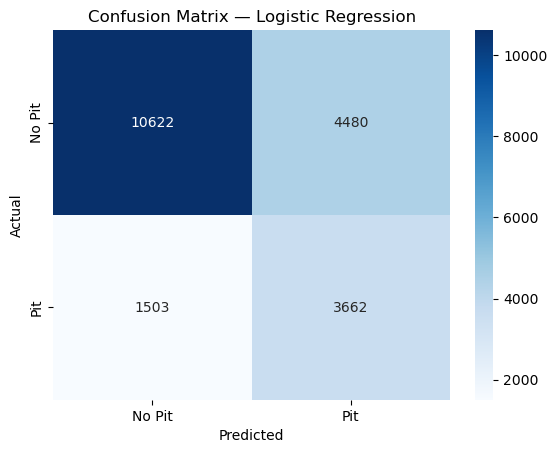

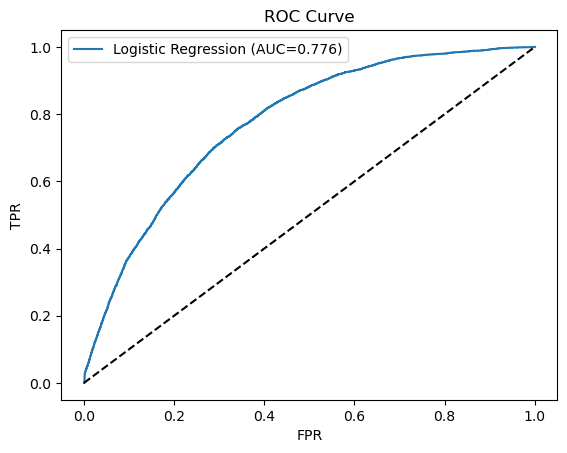


  Decision Tree  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0.91      0.71      0.80     15102
         Pit       0.49      0.81      0.61      5165

    accuracy                           0.73     20267
   macro avg       0.70      0.76      0.70     20267
weighted avg       0.80      0.73      0.75     20267

ROC-AUC:  0.8228
Avg Prec: 0.5646


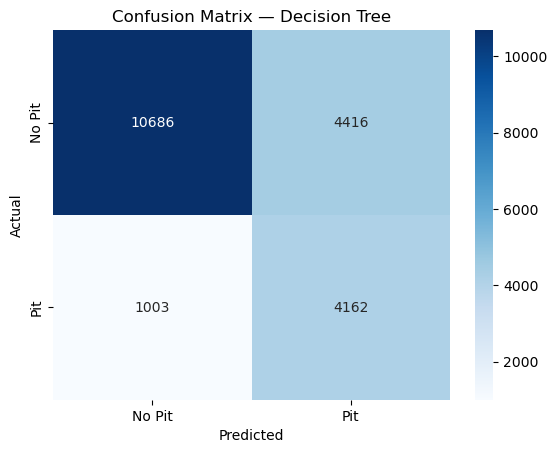

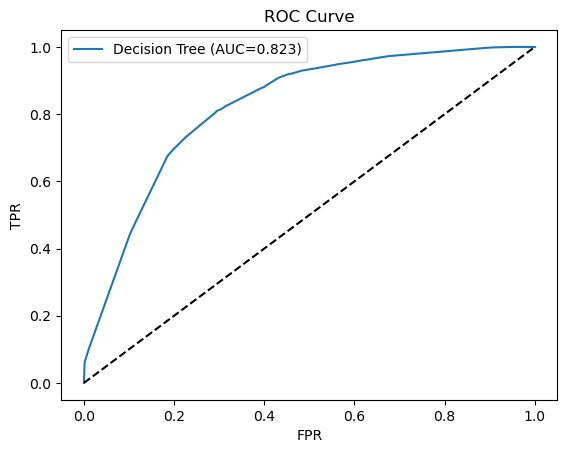


  Random Forest  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0.94      0.98      0.96     15102
         Pit       0.92      0.81      0.87      5165

    accuracy                           0.94     20267
   macro avg       0.93      0.90      0.91     20267
weighted avg       0.94      0.94      0.93     20267

ROC-AUC:  0.9797
Avg Prec: 0.9488


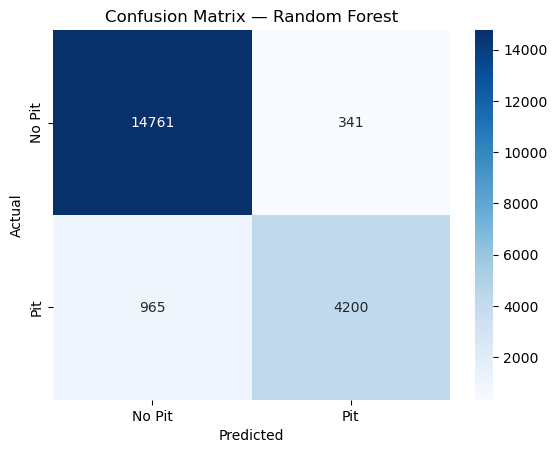

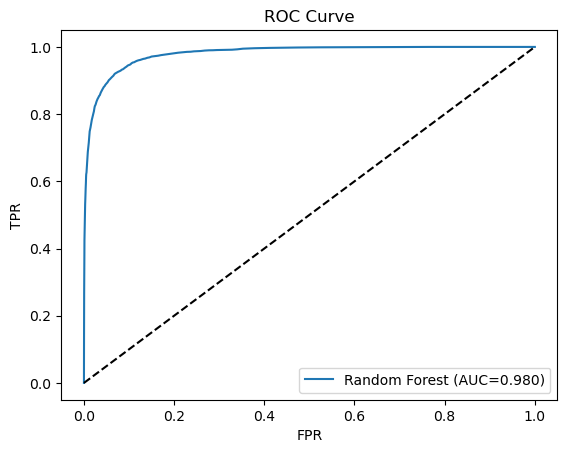

(array([0.275, 0.655, 0.6  , ..., 0.005, 0.005, 0.805], shape=(20267,)),
 array([0, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [154]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
evaluate_model(lr, X_test_scaled, y_test, "Logistic Regression")

# Decision Tree
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, X_test, y_test, "Decision Tree")

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test, "Random Forest")

# XGBoost Path

## Imbalance Handling

In [155]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg/pos
print(f"scale_pos_weight: {spw:.2f}")

scale_pos_weight: 2.92


### Base XGBoost

[0]	validation_0-auc:0.77828	validation_1-auc:0.77510
[50]	validation_0-auc:0.89715	validation_1-auc:0.89215
[100]	validation_0-auc:0.91947	validation_1-auc:0.91286
[150]	validation_0-auc:0.93152	validation_1-auc:0.92309
[200]	validation_0-auc:0.94291	validation_1-auc:0.93269
[250]	validation_0-auc:0.95015	validation_1-auc:0.93881
[300]	validation_0-auc:0.95692	validation_1-auc:0.94442
[350]	validation_0-auc:0.96208	validation_1-auc:0.94860
[400]	validation_0-auc:0.96629	validation_1-auc:0.95185
[450]	validation_0-auc:0.97015	validation_1-auc:0.95498
[499]	validation_0-auc:0.97338	validation_1-auc:0.95754

  XGBoost Base  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0.97      0.85      0.91     15102
         Pit       0.69      0.92      0.79      5165

    accuracy                           0.87     20267
   macro avg       0.83      0.89      0.85     20267
weighted avg       0.90      0.87      0.88     20267

ROC-AUC:  0.9575
Avg Prec: 

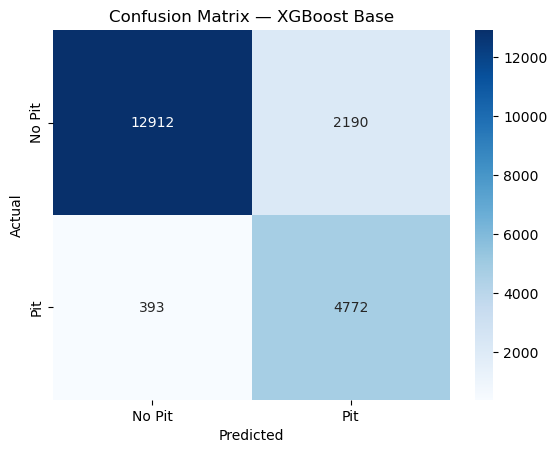

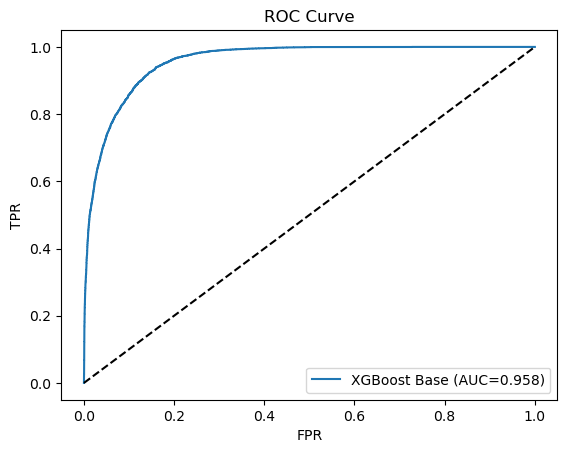

(array([0.732443  , 0.9645551 , 0.75339025, ..., 0.00150525, 0.00378305,
        0.9327634 ], shape=(20267,), dtype=float32),
 array([1, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [156]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train , y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50)
evaluate_model(xgb_model, X_test, y_test, "XGBoost Base")

# XGBoost Hyperparameter Tuning

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGB params: {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV AUC: 0.9869469275965382

  XGBOOST Tunned  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0.98      0.96      0.97     15102
         Pit       0.88      0.94      0.91      5165

    accuracy                           0.95     20267
   macro avg       0.93      0.95      0.94     20267
weighted avg       0.95      0.95      0.95     20267

ROC-AUC:  0.9880
Avg Prec: 0.9672


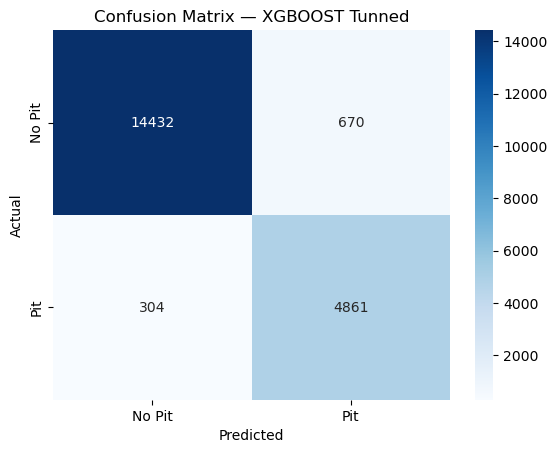

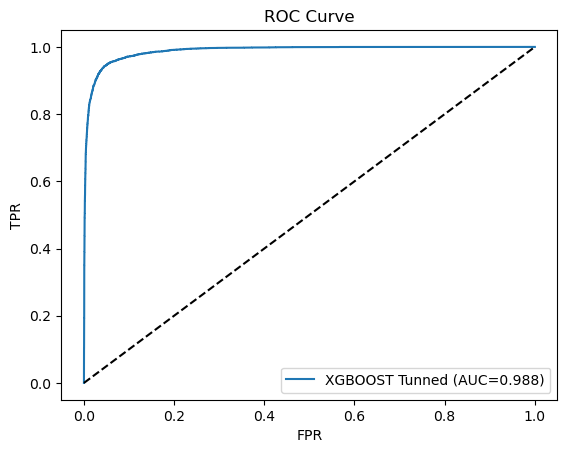

(array([6.9796658e-01, 9.8764127e-01, 6.1642146e-01, ..., 2.0377891e-05,
        4.0940777e-05, 9.5743132e-01], shape=(20267,), dtype=float32),
 array([1, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [157]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators':      [300, 500, 700],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 6, 8],
    'min_child_weight':  [1, 3, 5],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'gamma':             [0, 0.1, 0.3],
    'reg_alpha':         [0, 0.1, 0.5],   # L1
    'reg_lambda':        [1, 1.5, 2],      # L2
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb_search = RandomizedSearchCV(
    xgb_base,
    xgb_param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train)

print("Best XGB params:", xgb_search.best_params_)
print("Best CV AUC:",     xgb_search.best_score_)

xgb_tunned = xgb_search.best_estimator_
evaluate_model(xgb_tunned, X_test ,y_test, 'XGBOOST Tunned')

##  XGBoost Feature Importance

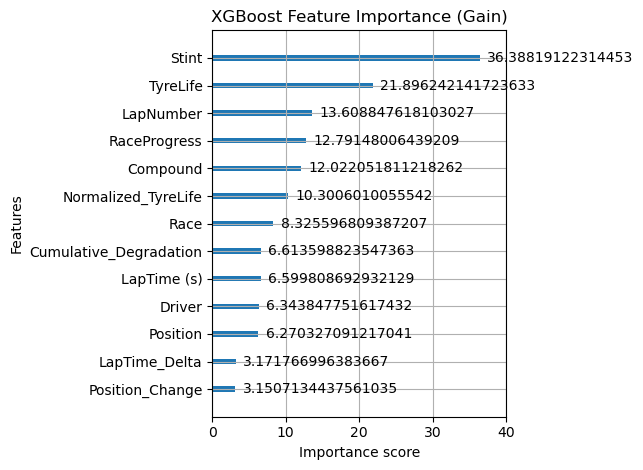

In [158]:
xgb.plot_importance(xgb_tunned, max_num_features=15, importance_type='gain')
plt.title('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()


# Threshold Optimisation (XGBoost)

Best threshold (F1): 0.60 → F1=0.9132


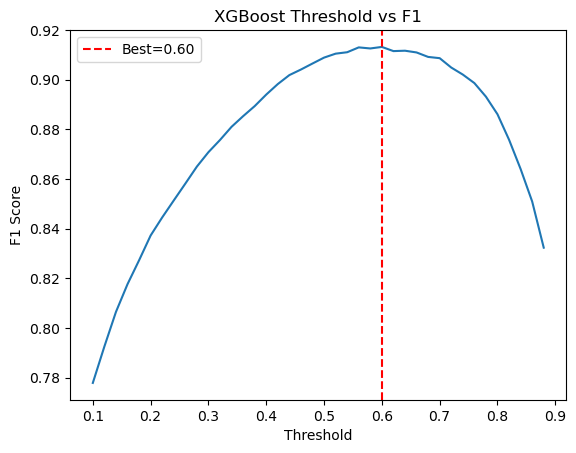


  XGBoost Tuned (Optimal Threshold)  (threshold=0.6000000000000001)
              precision    recall  f1-score   support

      No Pit       0.97      0.97      0.97     15102
         Pit       0.91      0.92      0.91      5165

    accuracy                           0.96     20267
   macro avg       0.94      0.94      0.94     20267
weighted avg       0.96      0.96      0.96     20267

ROC-AUC:  0.9880
Avg Prec: 0.9672


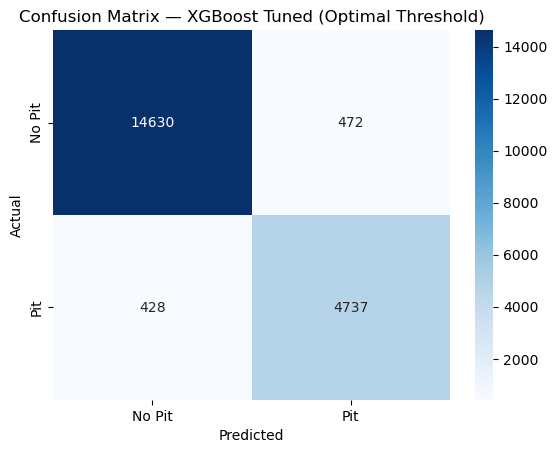

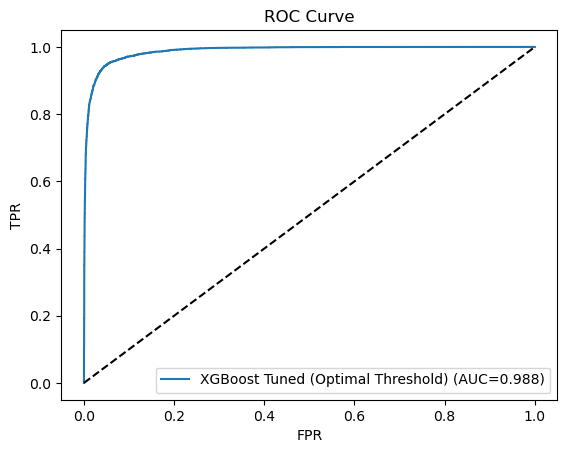

(array([6.9796658e-01, 9.8764127e-01, 6.1642146e-01, ..., 2.0377891e-05,
        4.0940777e-05, 9.5743132e-01], shape=(20267,), dtype=float32),
 array([1, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [159]:
y_prob_xgb = xgb_tunned.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.02)
f1_scores  = [f1_score(y_test, (y_prob_xgb >= t).astype(int)) for t in thresholds]

best_thresh_xgb = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (F1): {best_thresh_xgb:.2f} → F1={max(f1_scores):.4f}")

plt.plot(thresholds, f1_scores)
plt.axvline(best_thresh_xgb, color='red', linestyle='--', label=f'Best={best_thresh_xgb:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('XGBoost Threshold vs F1')
plt.legend()
plt.show()

evaluate_model(xgb_tunned, X_test, y_test, "XGBoost Tuned (Optimal Threshold)", threshold=best_thresh_xgb)

# LightGBM Path

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 20662, number of negative: 60406
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 81068, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

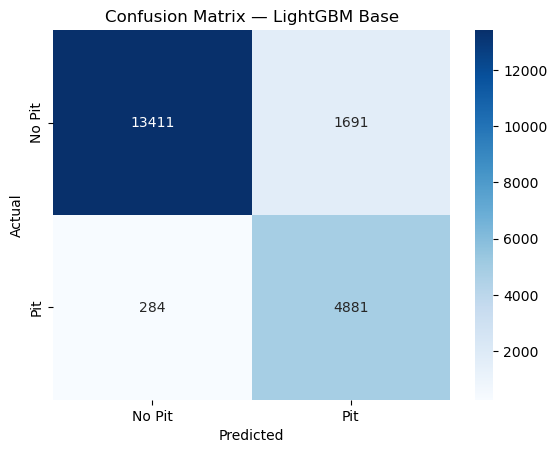

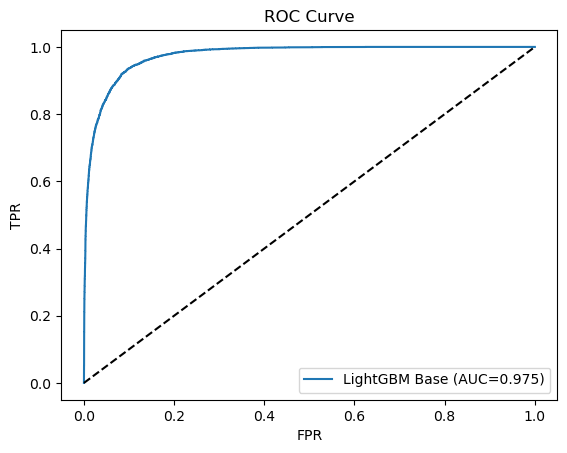

(array([7.23589575e-01, 9.12074370e-01, 6.59695343e-01, ...,
        4.37088347e-04, 2.57080759e-03, 9.54097485e-01], shape=(20267,)),
 array([1, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [160]:
X_lgb = df_lgb[feature_cols]
y_lgb = df_lgb[target_col]

X_train_lgb, X_test_lgb, y_train_lgb, y_test_lgb = train_test_split(
    X_lgb, y_lgb, test_size=0.2, random_state=42, stratify=y_lgb
)

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train_lgb, y_train_lgb,
    eval_set=[(X_test_lgb, y_test_lgb)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

evaluate_model(lgb_model, X_test_lgb, y_test_lgb, "LightGBM Base")

# LightGBM Hyperparameter Tuning

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 20662, number of negative: 60406
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 81068, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best LGB params: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0, 'num_leaves': 127, 'n_estimators': 700, 'min_split_gain': 0, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV AUC: 0.9933117303310125

  LightGBM Tuned  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0

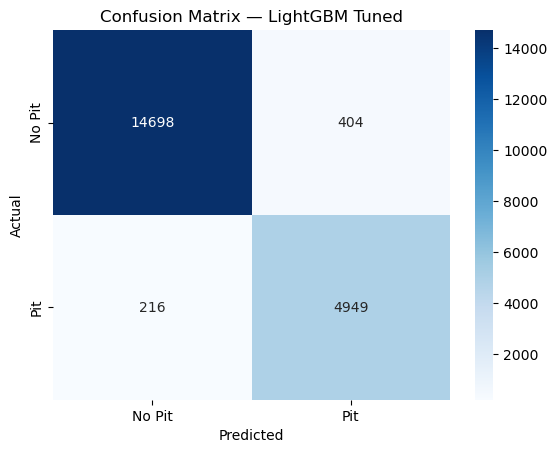

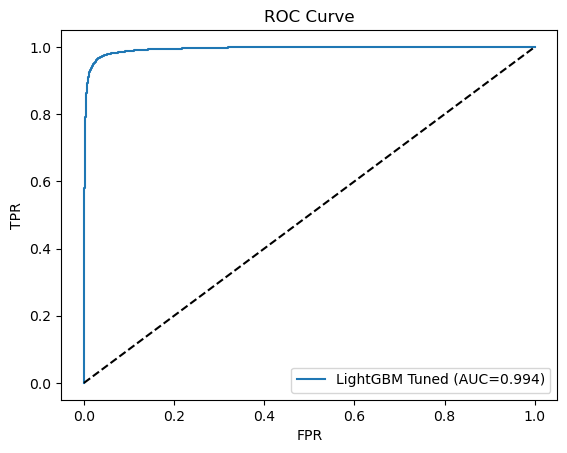

(array([1.31619083e-01, 9.83486711e-01, 6.25334066e-01, ...,
        1.05607146e-04, 1.79276525e-04, 9.91198040e-01], shape=(20267,)),
 array([0, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [161]:
lgb_param_grid = {
    'n_estimators':       [300, 500, 700],
    'learning_rate':      [0.01, 0.05, 0.1],
    'max_depth':          [4, 6, 8, -1],
    'num_leaves':         [31, 63, 127],
    'min_child_samples':  [10, 20, 50],
    'subsample':          [0.7, 0.8, 0.9],
    'colsample_bytree':   [0.6, 0.8, 1.0],
    'reg_alpha':          [0, 0.1, 0.5],
    'reg_lambda':         [0, 0.1, 0.5],
    'min_split_gain':     [0, 0.01, 0.1],
}

lgb_base = lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

lgb_search = RandomizedSearchCV(
    lgb_base,
    lgb_param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgb_search.fit(X_train_lgb, y_train_lgb)

print("Best LGB params:", lgb_search.best_params_)
print("Best CV AUC:",     lgb_search.best_score_)

lgb_tuned = lgb_search.best_estimator_
evaluate_model(lgb_tuned, X_test_lgb, y_test_lgb, "LightGBM Tuned")

# LightGBM Feature Importance

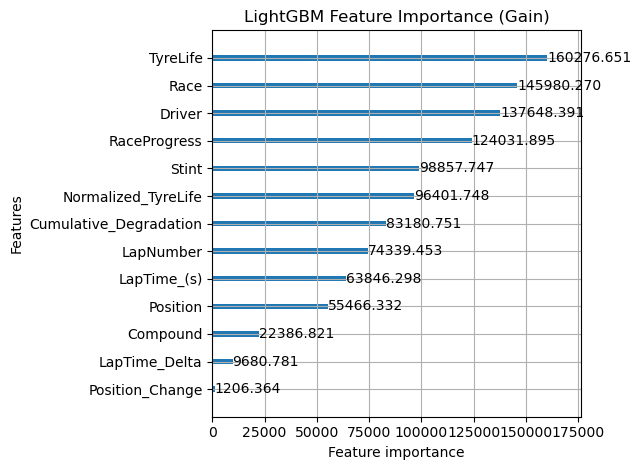

In [162]:
lgb.plot_importance(lgb_tuned, max_num_features=15, importance_type='gain')
plt.title('LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# Threshold Optimisation (LightGBM)

Best threshold (F1): 0.64 → F1=0.9445

  LightGBM Tuned (Optimal Threshold)  (threshold=0.6400000000000001)
              precision    recall  f1-score   support

      No Pit       0.98      0.98      0.98     15102
         Pit       0.95      0.93      0.94      5165

    accuracy                           0.97     20267
   macro avg       0.97      0.96      0.96     20267
weighted avg       0.97      0.97      0.97     20267

ROC-AUC:  0.9939
Avg Prec: 0.9834


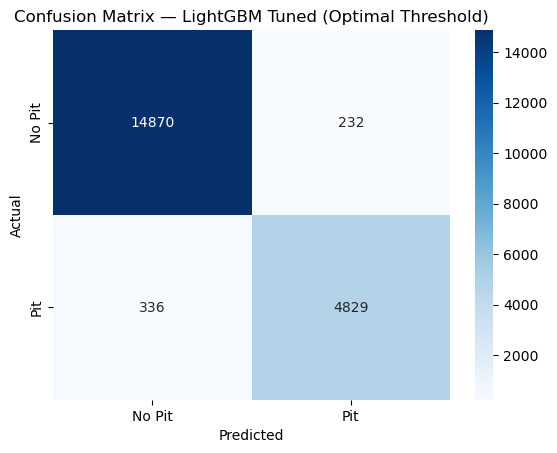

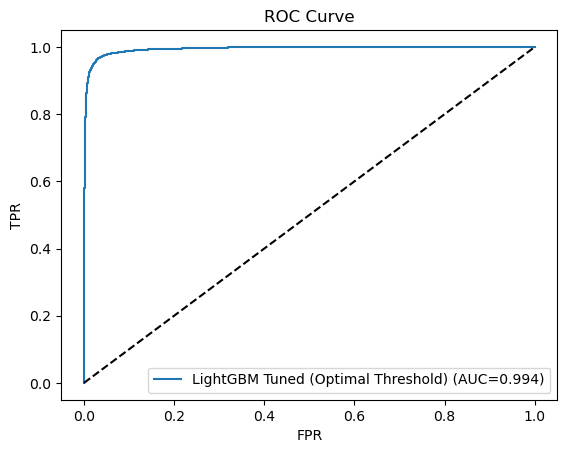

(array([1.31619083e-01, 9.83486711e-01, 6.25334066e-01, ...,
        1.05607146e-04, 1.79276525e-04, 9.91198040e-01], shape=(20267,)),
 array([0, 1, 0, ..., 0, 0, 1], shape=(20267,)))

In [163]:
y_prob_lgb = lgb_tuned.predict_proba(X_test_lgb)[:, 1]

f1_scores_lgb  = [f1_score(y_test_lgb, (y_prob_lgb >= t).astype(int)) for t in thresholds]
best_thresh_lgb = thresholds[np.argmax(f1_scores_lgb)]
print(f"Best threshold (F1): {best_thresh_lgb:.2f} → F1={max(f1_scores_lgb):.4f}")

evaluate_model(lgb_tuned, X_test_lgb, y_test_lgb, "LightGBM Tuned (Optimal Threshold)", threshold=best_thresh_lgb)

# Ensemble Learning
>  **Why ensemble?** XGBoost and LightGBM make different errors -
* combining them reduces variance and produces more stable predictions.

### Soft Voting Ensemble

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 20662, number of negative: 60406
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 81068, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

  Soft Voting Ensemble  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0.98      0.96      0.97     15102
         Pit       0.89      0.94      0.91      5165

    accuracy                           0.95     20267
   macro avg       0.93      0.95      0.94     20267
weighted avg       0.96      0.95      0.95     20267

ROC-AUC:  0.9889
Avg Prec: 0.9710


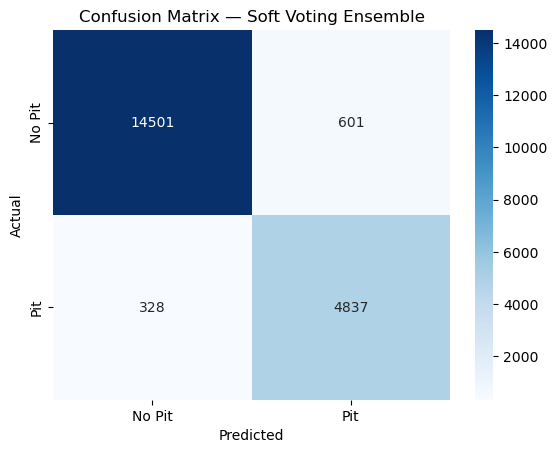

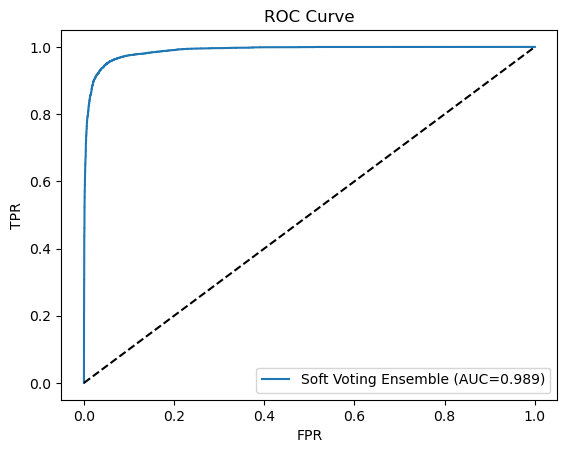

(array([0.57762294, 0.92171877, 0.63078076, ..., 0.00103311, 0.00111008,
        0.92845593], shape=(20267,)),
 array([1, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [164]:
# Voting = average predicted probabilities
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_tunned),
        ('lgb', lgb_tuned),
        ('rf',  rf)
    ],
    voting='soft',
    weights=[2, 2, 1]   # trust XGB/LGB more than RF
)

voting_clf.fit(X_train, y_train)
evaluate_model(voting_clf, X_test, y_test, "Soft Voting Ensemble")

# Stacking Ensemble


  Stacking Ensemble  (threshold=0.5)
              precision    recall  f1-score   support

      No Pit       0.98      0.95      0.97     15102
         Pit       0.87      0.95      0.91      5165

    accuracy                           0.95     20267
   macro avg       0.93      0.95      0.94     20267
weighted avg       0.95      0.95      0.95     20267

ROC-AUC:  0.9890
Avg Prec: 0.9687


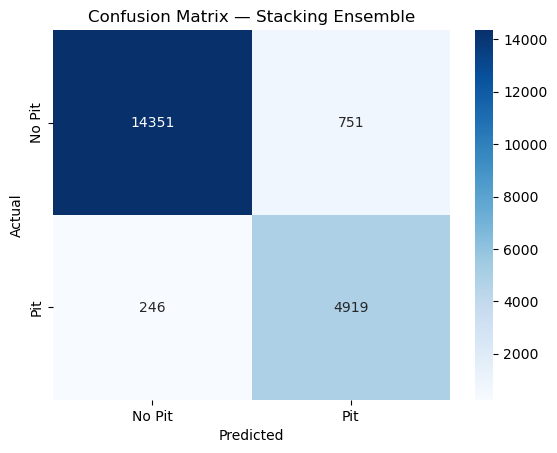

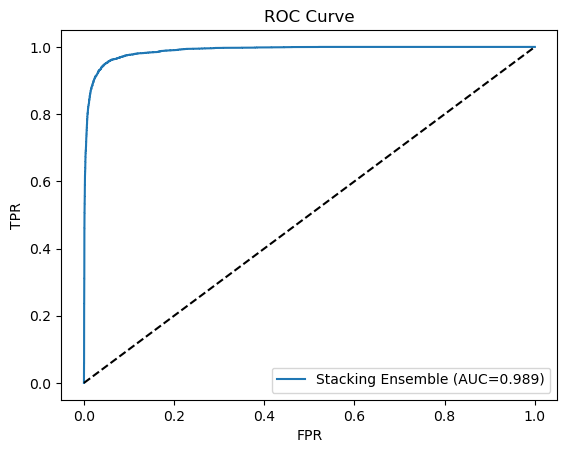

(array([0.82833058, 0.99117808, 0.76530375, ..., 0.01493121, 0.01495308,
        0.9877742 ], shape=(20267,)),
 array([1, 1, 1, ..., 0, 0, 1], shape=(20267,)))

In [165]:
stacking_clf = StackingClassifier(
    estimators= [
        ('xgb' , xgb_tunned), 
        ('lgb' , lgb_tuned), 
        ('rf' , rf)
        
    ], 
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False,    # only meta-features to final estimator
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)
evaluate_model(stacking_clf, X_test, y_test, "Stacking Ensemble")


#  Manual Blending (Weighted Average)

In [166]:

# Blend probabilities directly — most flexible
y_prob_xgb   = xgb_tunned.predict_proba(X_test)[:, 1]
y_prob_lgb   = lgb_tuned.predict_proba(X_test_lgb)[:, 1]
y_prob_rf    = rf.predict_proba(X_test)[:, 1]

# Optimise weights or use domain knowledge
w_xgb, w_lgb, w_rf = 0.4, 0.4, 0.2
y_prob_blend = w_xgb*y_prob_xgb + w_lgb*y_prob_lgb + w_rf*y_prob_rf

# Find best threshold on blended probs
f1_blend = [f1_score(y_test, (y_prob_blend >= t).astype(int)) for t in thresholds]
best_thresh_blend = thresholds[np.argmax(f1_blend)]

y_pred_blend = (y_prob_blend >= best_thresh_blend).astype(int)
print(f"Blend AUC:  {roc_auc_score(y_test, y_prob_blend):.4f}")
print(f"Blend F1:   {f1_score(y_test, y_pred_blend):.4f}  (threshold={best_thresh_blend:.2f})")
print(classification_report(y_test, y_pred_blend, target_names=['No Pit','Pit']))

Blend AUC:  0.9920
Blend F1:   0.9332  (threshold=0.54)
              precision    recall  f1-score   support

      No Pit       0.98      0.98      0.98     15102
         Pit       0.93      0.94      0.93      5165

    accuracy                           0.97     20267
   macro avg       0.95      0.96      0.96     20267
weighted avg       0.97      0.97      0.97     20267



# Ensemble Comparison

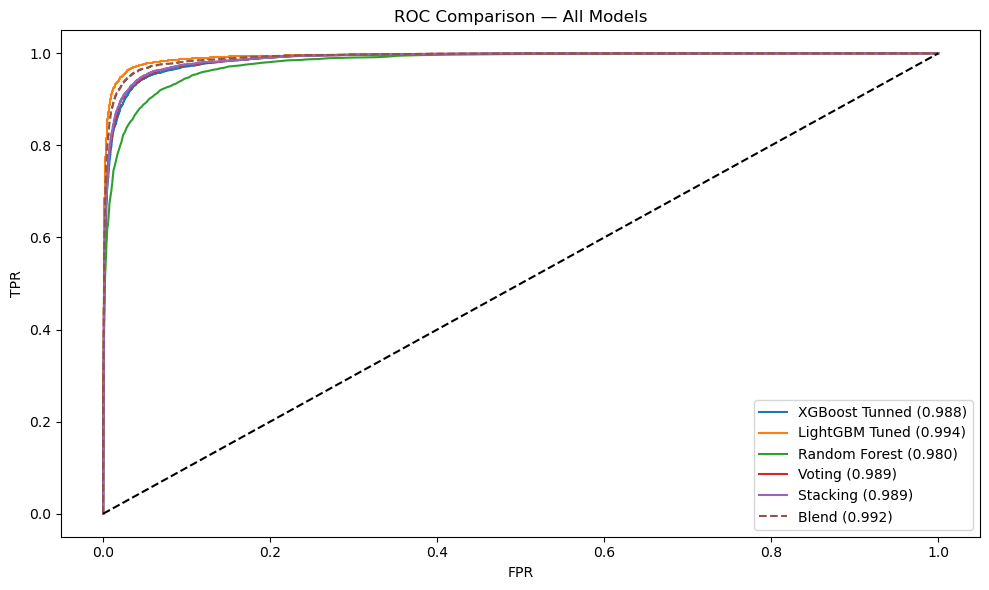

         Model  ROC-AUC  Avg Precision
LightGBM Tuned 0.993875       0.983380
      Stacking 0.989028       0.968662
        Voting 0.988876       0.971049
XGBoost Tunned 0.987983       0.967216
 Random Forest 0.979672       0.948764


In [167]:
models = {
    'XGBoost Tunned':   (xgb_tunned, X_test),
    'LightGBM Tuned':  (lgb_tuned, X_test_lgb),
    'Random Forest':   (rf,         X_test),
    'Voting':          (voting_clf, X_test),
    'Stacking':        (stacking_clf, X_test),
}

plt.figure(figsize=(10,6))
results = []

for name, (model, X_eval) in models.items():
    y_prob = model.predict_proba(X_eval)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    ap     = average_precision_score(y_test, y_prob)
    results.append({'Model': name, 'ROC-AUC': auc, 'Avg Precision': ap})
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} ({auc:.3f})')

# Add blended
auc_b = roc_auc_score(y_test, y_prob_blend)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_blend)
plt.plot(fpr_b, tpr_b, label=f'Blend ({auc_b:.3f})', linestyle='--')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Comparison — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

# Overfitting / Underfitting Checks

In [169]:
# def train_test_gap(model, X_train, y_train, X_test, y_test, model_name):
#     train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
#     test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test)[:,1])
#     gap       = train_auc - test_auc

#     print(f"\n{model_name}")
#     print(f"  Train AUC : {train_auc:.4f}")
#     print(f"  Test AUC  : {test_auc:.4f}")
#     print(f"  Gap       : {gap:.4f}  ", end='')

#     if gap > 0.05:
#         print("OVERFITTING — regularise or reduce complexity")
#     elif test_auc < 0.70:
#         print("UNDERFITTING — model too simple or bad features")
#     else:
#         print("Good generalisation")

# for name, (model, X_eval) in models.items():
#     train_test_gap(model, X_train, y_train, X_eval, y_test, name)

In [ ]:
# cat_cols = ['Driver', 'Compound', 'Race']

# # Convert entire dataset BEFORE train-test split
# for col in cat_cols:
#     df[col] = df[col].astype('category')

# X = df.drop('PitNextLap', axis=1)
# y = df['PitNextLap']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# # Ensure test categories match train categories
# for col in cat_cols:
#     X_test[col] = pd.Categorical(
#         X_test[col],
#         categories=X_train[col].cat.categories
#     )

# lgb_model = lgb.LGBMClassifier(random_state=42,n_estimators=200)

# lgb_model.fit( X_train, y_train, categorical_feature=cat_cols)
# # Evaluate
# train_test_gap( lgb_model, X_train, y_train, X_test, y_test, "LightGBM")

In [170]:
# ── Val splits for early stopping ──
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)
X_tr_lgb, X_val_lgb, y_tr_lgb, y_val_lgb = train_test_split(
    X_train_lgb, y_train_lgb, test_size=0.15, random_state=42, stratify=y_train_lgb
)

# ── RF (add constraints) ──
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=10,
    min_samples_split=20, class_weight='balanced', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

# ── XGB base (val set, regularisation) ──
xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.5,
    scale_pos_weight=spw, eval_metric='auc',
    early_stopping_rounds=50, random_state=42, n_jobs=-1
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=50)

# ── XGB param grid ──
xgb_param_grid = {
    'n_estimators':     [300, 500, 700],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [3, 4, 5],
    'min_child_weight': [3, 5, 10],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma':            [0.1, 0.3, 0.5],
    'reg_alpha':        [0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 1.5, 2.0],
}

# ── LGB base (val set, fixed num_leaves) ──
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=5,
    num_leaves=25, min_child_samples=30, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1
)
lgb_model.fit(
    X_tr_lgb, y_tr_lgb,
    eval_set=[(X_val_lgb, y_val_lgb)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

# ── LGB param grid ──
lgb_param_grid = {
    'n_estimators':      [300, 500, 700],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 5, 6],
    'num_leaves':        [15, 25, 31],
    'min_child_samples': [20, 30, 50],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'reg_alpha':         [0.1, 0.5, 1.0],
    'reg_lambda':        [0.1, 0.5, 1.0],
    'min_split_gain':    [0.01, 0.1, 0.2],
}

# ── Gap check (fixed LGB y_test) ──
def train_test_gap(model, X_train, y_train, X_test, y_test, model_name):
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test)[:, 1])
    gap       = train_auc - test_auc
    print(f"\n{model_name}")
    print(f"  Train AUC : {train_auc:.4f}")
    print(f"  Test AUC  : {test_auc:.4f}")
    print(f"  Gap       : {gap:.4f}  ", end='')
    if gap > 0.05:   print("OVERFITTING")
    elif test_auc < 0.70: print("UNDERFITTING")
    else:            print("Good generalisation")

train_test_gap(xgb_tunned, X_train,     y_train,     X_test,     y_test,     "XGBoost Tuned")
train_test_gap(lgb_tuned,  X_train_lgb, y_train_lgb, X_test_lgb, y_test_lgb, "LightGBM Tuned")  # fixed
train_test_gap(rf,         X_train,     y_train,     X_test,     y_test,     "Random Forest")

[0]	validation_0-auc:0.73098	validation_1-auc:0.73423
[50]	validation_0-auc:0.86413	validation_1-auc:0.85665
[100]	validation_0-auc:0.88690	validation_1-auc:0.87911
[150]	validation_0-auc:0.89955	validation_1-auc:0.89156
[200]	validation_0-auc:0.90859	validation_1-auc:0.90059
[250]	validation_0-auc:0.91605	validation_1-auc:0.90814
[300]	validation_0-auc:0.92243	validation_1-auc:0.91444
[350]	validation_0-auc:0.92721	validation_1-auc:0.91896
[400]	validation_0-auc:0.93086	validation_1-auc:0.92253
[450]	validation_0-auc:0.93417	validation_1-auc:0.92566
[500]	validation_0-auc:0.93699	validation_1-auc:0.92855
[550]	validation_0-auc:0.93961	validation_1-auc:0.93097
[600]	validation_0-auc:0.94251	validation_1-auc:0.93350
[650]	validation_0-auc:0.94480	validation_1-auc:0.93558
[700]	validation_0-auc:0.94670	validation_1-auc:0.93721
[750]	validation_0-auc:0.94849	validation_1-auc:0.93871
[800]	validation_0-auc:0.95033	validation_1-auc:0.94025
[850]	validation_0-auc:0.95220	validation_1-auc:0.9

# Cross-Validation (5-Fold Stratified)

In [173]:
def cv_check(model, X, y, model_name, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

    print(f"\n{model_name} — CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Folds: {[f'{s:.4f}' for s in scores]}")

    if scores.std() > 0.02:
        print("High variance across folds — possible overfitting or unstable model")
    else:
        print(" Stable across folds")

    return scores

cv_xgb = cv_check(xgb_tunned, X, y, "XGBoost Tunned")
cv_lgb = cv_check(lgb_tuned, X_lgb, y_lgb, "LightGBM Tuned")
cv_rf  = cv_check(rf,        X, y, "Random Forest")


XGBoost Tunned — CV AUC: 0.9894 ± 0.0005
  Folds: ['0.9899', '0.9886', '0.9894', '0.9891', '0.9901']
 Stable across folds

LightGBM Tuned — CV AUC: 0.9949 ± 0.0002
  Folds: ['0.9951', '0.9947', '0.9948', '0.9948', '0.9950']
 Stable across folds

Random Forest — CV AUC: 0.9142 ± 0.0015
  Folds: ['0.9139', '0.9121', '0.9146', '0.9138', '0.9167']
 Stable across folds


# Learning Curves

### AUC = Area Under the ROC Curve.
> ROC plots True Positive Rate vs False Positive Rate at every threshold. AUC = area under that curve.

* 1.0 = perfect model
* 0.5 = random guessing
* < 0.5 = worse than random

- Tells you: how well model separates pit vs no-pit across all thresholds, independent of which threshold you pick. Better than accuracy on imbalanced data like yours.

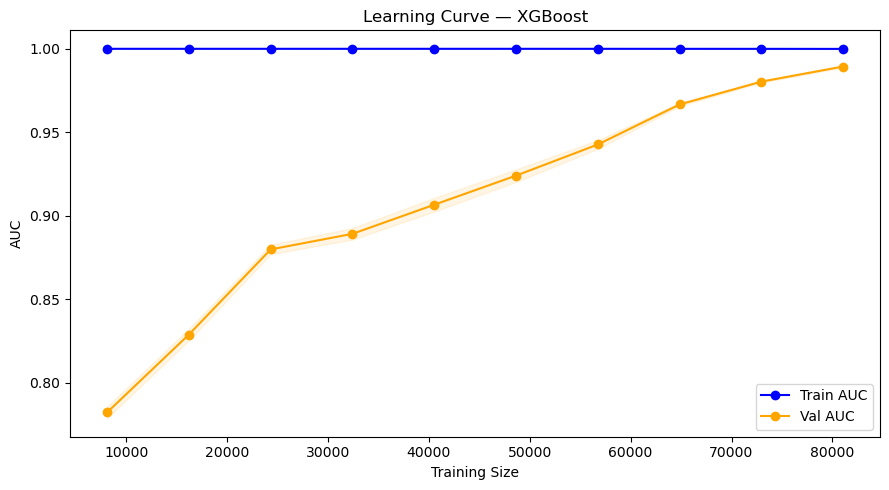

  Healthy learning curve (gap=0.011, val_auc=0.989)


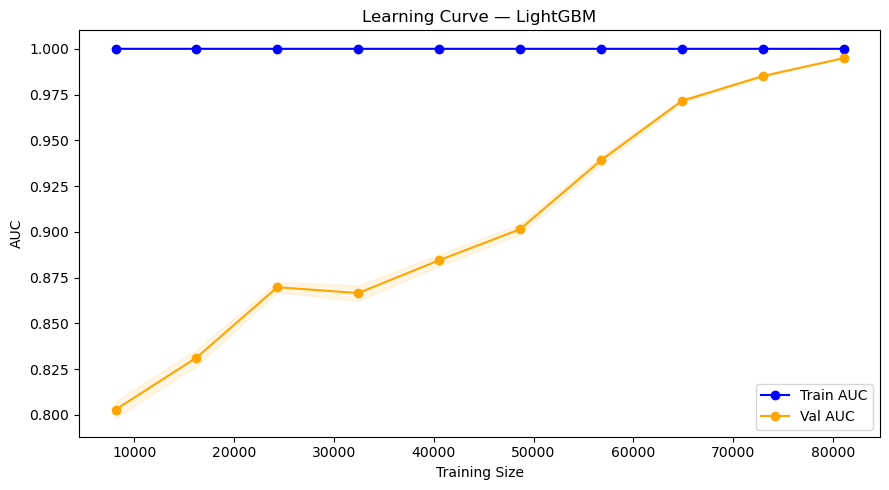

  Healthy learning curve (gap=0.005, val_auc=0.995)


In [176]:
def plot_learning_curve(model, X, y, model_name, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    
    plt.figure(figsize=(9,5))
    plt.plot(train_sizes, train_mean, 'o-', color='blue',  label='Train AUC')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean,   'o-', color='orange', label='Val AUC')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='orange')
    plt.xlabel('Training Size')
    plt.ylabel('AUC')
    plt.title(f'Learning Curve — {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Diagnosis
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.05:
        print(f"  ⚠️  Train-Val gap={gap:.3f} → Overfitting. Try: more data, stronger regularisation, lower depth.")
    elif val_mean[-1] < 0.70:
        print(f" Val AUC={val_mean[-1]:.3f} → Underfitting. Try: more features, deeper model, less regularisation.")
    else:
        print(f"  Healthy learning curve (gap={gap:.3f}, val_auc={val_mean[-1]:.3f})")

plot_learning_curve(xgb_tunned, X, y, "XGBoost")
plot_learning_curve(lgb_tuned, X_lgb, y_lgb, "LightGBM")

#  Validation Curve (Single Hyperparameter)

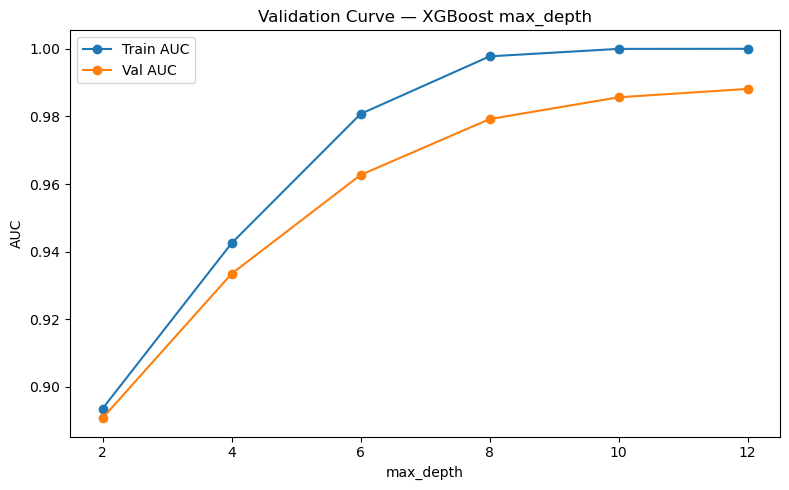

In [178]:
from sklearn.model_selection import validation_curve

# Check XGBoost max_depth
param_range = [2, 4, 6, 8, 10, 12]

train_scores, val_scores = validation_curve(
    xgb.XGBClassifier(scale_pos_weight=spw, random_state=42, n_jobs=-1),
    X_train, y_train,
    param_name='max_depth',
    param_range=param_range,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(param_range, train_scores.mean(axis=1), 'o-', label='Train AUC')
plt.plot(param_range, val_scores.mean(axis=1),   'o-', label='Val AUC')
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Validation Curve — XGBoost max_depth')
plt.legend()
plt.tight_layout()
plt.show()
# Sweet spot = where val AUC peaks before overfitting starts

# Precision-Recall Curve

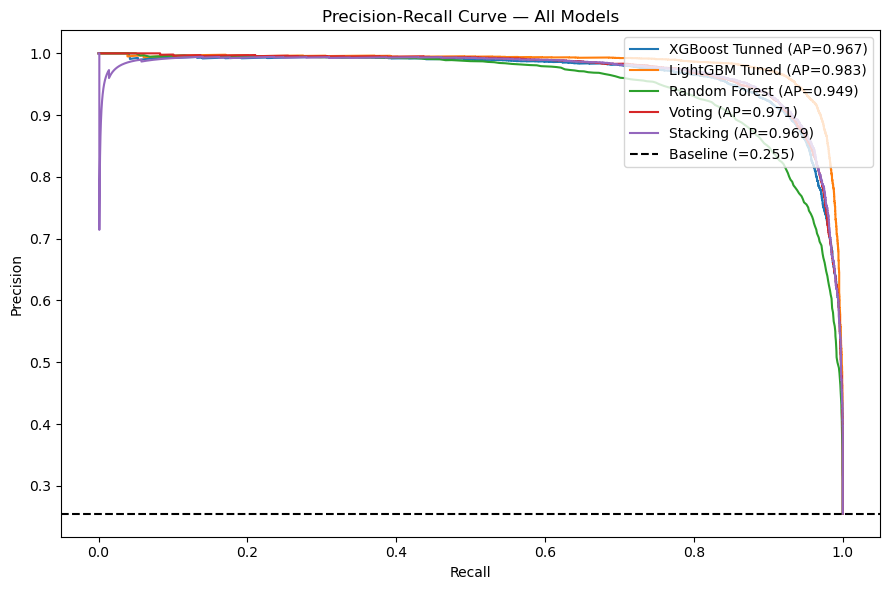

In [179]:
# More informative than ROC for imbalanced data
plt.figure(figsize=(9,6))

for name, (model, X_eval) in models.items():
    y_prob = model.predict_proba(X_eval)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

# Baseline (random classifier)
plt.axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline (={y_test.mean():.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All Models')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Residual / Calibration Check

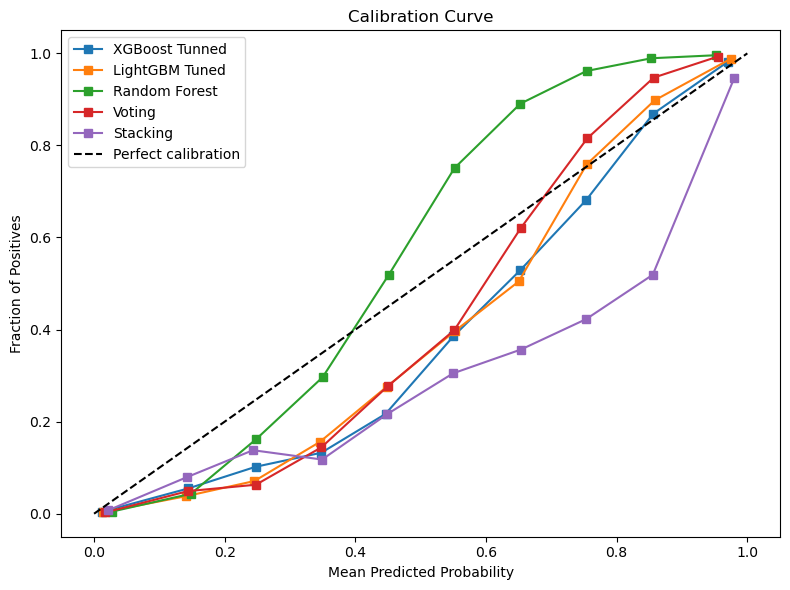

In [180]:

from sklearn.calibration import calibration_curve

plt.figure(figsize=(8,6))

for name, (model, X_eval) in models.items():
    y_prob = model.predict_proba(X_eval)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(mean_pred, frac_pos, 's-', label=name)

plt.plot([0,1],[0,1],'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.tight_layout()
plt.show()
# Model overestimates: curve above diagonal
# Model underestimates: curve below diagonal

# Summary Diagnosis Table

In [183]:
diagnosis = []
for name, (model, X_eval) in models.items():
    # use correct train set for LGB
    X_tr_use = X_train_lgb if name == 'LightGBM Tuned' else X_train
    y_tr_use = y_train_lgb if name == 'LightGBM Tuned' else y_train
    y_te_use = y_test_lgb  if name == 'LightGBM Tuned' else y_test

    train_auc = roc_auc_score(y_tr_use, model.predict_proba(X_tr_use)[:,1])
    test_auc  = roc_auc_score(y_te_use, model.predict_proba(X_eval)[:,1])
    gap       = train_auc - test_auc

    if gap > 0.05:      verdict = 'Overfitting'
    elif test_auc < 0.70: verdict = 'Underfitting'
    else:               verdict = 'Good'

    diagnosis.append({
        'Model':     name,
        'Train AUC': round(train_auc, 4),
        'Test AUC':  round(test_auc,  4),
        'Gap':       round(gap, 4),
        'Verdict':   verdict
    })

print(pd.DataFrame(diagnosis).to_string(index=False))

         Model  Train AUC  Test AUC    Gap Verdict
XGBoost Tunned     1.0000    0.9880 0.0120    Good
LightGBM Tuned     1.0000    0.9939 0.0061    Good
 Random Forest     1.0000    0.9797 0.0203    Good
        Voting     1.0000    0.9889 0.0111    Good
      Stacking     0.9999    0.9890 0.0109    Good


# Fine-Tuning Strategies
> If Overfitting (Train AUC >> Test AUC)

### If Underfitting (Both Train & Test AUC low)

- Add features: `TyreLife²`, `LapTime_Delta × TyreLife` interaction, rolling lap time avg
- Increase depth: `max_depth=8-10`
- More trees: `n_estimators=1000`
- Add `Stint`, `RaceProgress` binned versions
- Check if target encoding gives signal on Driver/Race

# Imbalance Fixes

In [184]:
# Option 1: SMOTE (oversample minority class)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# Option 2: scale_pos_weight (XGBoost built-in)
# Already set above

# Option 3: class_weight='balanced' (sklearn models)
# Already set above

# Option 4: Adjust decision threshold (covered in 8.5 / 9.4)

# Final Model Selection


  FINAL MODEL  (threshold=0.54)
              precision    recall  f1-score   support

      No Pit       0.98      0.95      0.97     15102
         Pit       0.87      0.95      0.91      5165

    accuracy                           0.95     20267
   macro avg       0.93      0.95      0.94     20267
weighted avg       0.95      0.95      0.95     20267

ROC-AUC:  0.9890
Avg Prec: 0.9687


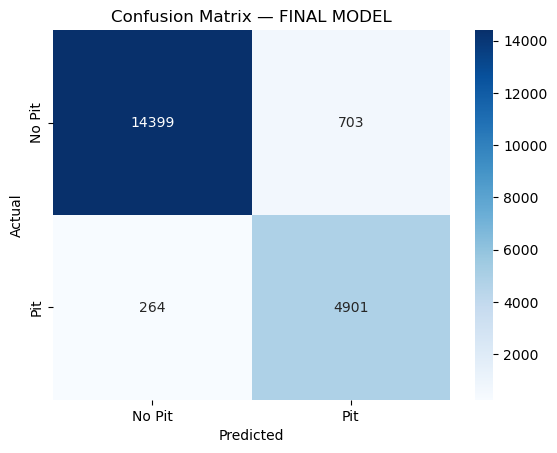

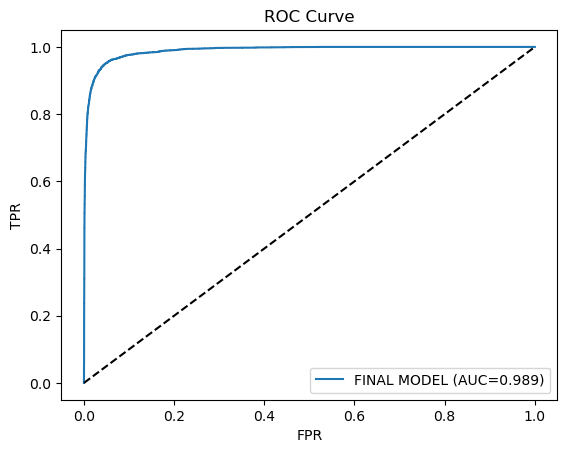

Model saved.


In [185]:

# Pick best model from comparison table
# Criteria: highest Test AUC + good calibration + no overfitting

# Example: if stacking wins
final_model = stacking_clf
final_threshold = best_thresh_blend  # or tune on val set

# Final eval
evaluate_model(final_model, X_test, y_test, "FINAL MODEL", threshold=final_threshold)

# Save
import joblib
joblib.dump(final_model, 'f1_pitstop_model.pkl')
joblib.dump(scaler,      'f1_scaler.pkl')

print("Model saved.")